# **Algeria Telecom - Comprehensive Data Analysis**
## **Project Overview**
This project presents a comprehensive analysis of Algeria Telecom's internet data, focusing on subscriber trends, technology adoption, and revenue metrics from 2018 to 2025.This project presents a comprehensive analysis of Algeria Telecom's internet data, focusing on subscriber trends, technology adoption, and revenue metrics from 2018 to 2025.

## **Key Objectives:**
- Load and preprocess Algeria Telecom's internet data

- Perform exploratory data analysis (EDA)

- Create interactive visualizations and dashboards

- Analyze trends in internet technologies and subscriber growth

## **Dataset Information**
**Time Period:** Quarterly data from 2018-T4 to 2025-T1 (26 periods)

**Key Metrics Tracked:**

- Total Internet Subscribers

- ADSL, Fixed 4G LTE, Fiber FTTH subscribers

- Mobile 3G/4G subscribers

- Total traffic consumption

- Average Revenue Per User (ARPU)

# **1. SETUP AND INSTALLATIONS**

In [ ]:
!pip install prophet
!pip install tensorflow
!pip install xgboost
!pip install lightgbm
!pip install statsmodels
!pip install pmdarima
!pip install plotly
!pip install scikit-learn

print("✅ All packages installed successfully!")

# **2. IMPORTS AND CONFIGURATION**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Advanced ML imports
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, IsolationForest
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
import xgboost as xgb
import lightgbm as lgb

# Time series specific imports
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
from scipy import stats

print("="*80)
print("🇩🇿 ALGERIA TELECOM - COMPREHENSIVE DATA ANALYSIS")
print("Advanced Analytics and Forecasting")
print("="*80)

# **3. LOADING ALGERIA TELECOM DATASET**

In [ ]:
def load_and_preprocess_data():
    """Load data from CSV file and preprocess for analysis"""

    print("📊 LOADING ALGERIA TELECOM DATASET")
    print("-" * 40)

    # Read the CSV file
    df_raw = pd.read_csv('internet_data.csv', index_col=0)

    print(f"✅ Data loaded successfully")
    print(f"   • Shape: {df_raw.shape}")
    print(f"   • Metrics: {df_raw.shape[0]}")
    print(f"   • Time periods: {df_raw.shape[1]}")

    # Transpose to have time periods as rows
    df = df_raw.T

    # Clean column names
    column_mapping = {
        'Parc_global_des_abonnés_Internet': 'Total_Internet_Subscribers',
        'Abonnés_ADSL': 'ADSL_Subscribers',
        'Abonnés_Internet_4G_LTE_fixe': 'Fixed_4G_LTE_Subscribers',
        'Abonnés_Internet_fibre_FTTH': 'Fiber_FTTH_Subscribers',
        'Abonnés_actifs_de_l\'Internet_mobile 3G/4G': 'Mobile_3G_4G_Subscribers',
        '3G': '3G_Subscribers',
        '4G': '4G_Subscribers',
        'Total_du_trafic_consommé': 'Total_Traffic_Consumed',
        'Revenu_mensuel_moyenpar_abonné(DA)': 'Average_Revenue_Per_User_DA'
    }

    df.columns = [column_mapping.get(col, col) for col in df.columns]

    # Clean data - remove spaces and convert to numeric
    for col in df.columns:
        if df[col].dtype == 'object':
            df[col] = df[col].astype(str).str.replace(' ', '').str.replace(',', '').str.replace('**', '')
            df[col] = pd.to_numeric(df[col], errors='coerce')

    # Create proper date column
    def parse_period(period_str):
        try:
            year, quarter = period_str.split('_T')
            quarter_month = {'1': '01', '2': '04', '3': '07', '4': '10'}
            return pd.to_datetime(f"{year}-{quarter_month[quarter]}-01")
        except:
            return pd.NaT

    df['Period'] = df.index
    df['Date'] = df.index.map(parse_period)
    df['Year'] = df['Date'].dt.year
    df['Quarter'] = df['Date'].dt.quarter

    # Reset index and sort by date
    df = df.reset_index(drop=True)
    df = df.sort_values('Date').reset_index(drop=True)

    print(f"\n📈 Data preprocessing completed:")
    print(f"   • Time range: {df['Date'].min().strftime('%Y-%m')} to {df['Date'].max().strftime('%Y-%m')}")
    print(f"   • Total periods: {len(df)}")

    return df

# Load the data
df = load_and_preprocess_data()

# Display sample data
print(f"\n📊 Sample Data:")
display_cols = ['Period', 'Date', 'Total_Internet_Subscribers', 'ADSL_Subscribers',
               'Fiber_FTTH_Subscribers', '4G_Subscribers', 'Average_Revenue_Per_User_DA']
print(df[display_cols].head())

# **4. COMPREHENSIVE EXPLORATORY DATA ANALYSIS**

In [ ]:
def comprehensive_eda(df):
    """Comprehensive Exploratory Data Analysis"""

    print("📊 COMPREHENSIVE EXPLORATORY DATA ANALYSIS")
    print("="*50)

    # Basic data info
    print("📋 Dataset Overview:")
    print(f"   • Total periods: {len(df)}")
    print(f"   • Time span: {df['Date'].min().strftime('%Y-%m')} to {df['Date'].max().strftime('%Y-%m')}")
    print(f"   • Data frequency: Quarterly")

    # Missing data analysis
    print(f"\n🔍 Data Quality Assessment:")
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        if col not in ['Year', 'Quarter']:
            missing_pct = (df[col].isna().sum() / len(df)) * 100
            status = "✅" if missing_pct == 0 else "⚠️" if missing_pct < 20 else "❌"
            print(f"   {status} {col}: {missing_pct:.1f}% missing")

    # Summary statistics
    print(f"\n📈 Key Metrics Summary:")
    key_metrics = ['Total_Internet_Subscribers', 'ADSL_Subscribers', 'Fixed_4G_LTE_Subscribers',
                   'Fiber_FTTH_Subscribers', '3G_Subscribers', '4G_Subscribers', 'Total_Traffic_Consumed']

    summary_stats = {}
    for metric in key_metrics:
        if metric in df.columns:
            data = df[metric].fillna(0) if metric == 'Fiber_FTTH_Subscribers' else df[metric]
            summary_stats[metric] = {
                'current': data.iloc[-1],
                'max': data.max(),
                'min': data.min(),
                'mean': data.mean(),
                'growth': ((data.iloc[-1] - data.iloc[0]) / data.iloc[0] * 100) if data.iloc[0] > 0 else 0
            }

            print(f"   • {metric}:")
            print(f"     Current: {summary_stats[metric]['current']:,.0f}")
            print(f"     Growth: {summary_stats[metric]['growth']:+.1f}%")

    # ARPU analysis if available
    if 'Average_Revenue_Per_User_DA' in df.columns:
        arpu_data = df[df['Average_Revenue_Per_User_DA'].notna()]
        if len(arpu_data) > 0:
            current_arpu = arpu_data['Average_Revenue_Per_User_DA'].iloc[-1]
            arpu_growth = ((arpu_data['Average_Revenue_Per_User_DA'].iloc[-1] -
                           arpu_data['Average_Revenue_Per_User_DA'].iloc[0]) /
                           arpu_data['Average_Revenue_Per_User_DA'].iloc[0] * 100)
            print(f"   • Average Revenue Per User:")
            print(f"     Current ARPU: {current_arpu:.2f} DA")
            print(f"     ARPU Growth: {arpu_growth:+.1f}%")

    return summary_stats

# Run EDA
eda_results = comprehensive_eda(df)

# **5. CREATING COMPREHENSIVE VISUALIZATION DASHBOARD**

📊 CREATING COMPREHENSIVE VISUALIZATION DASHBOARD


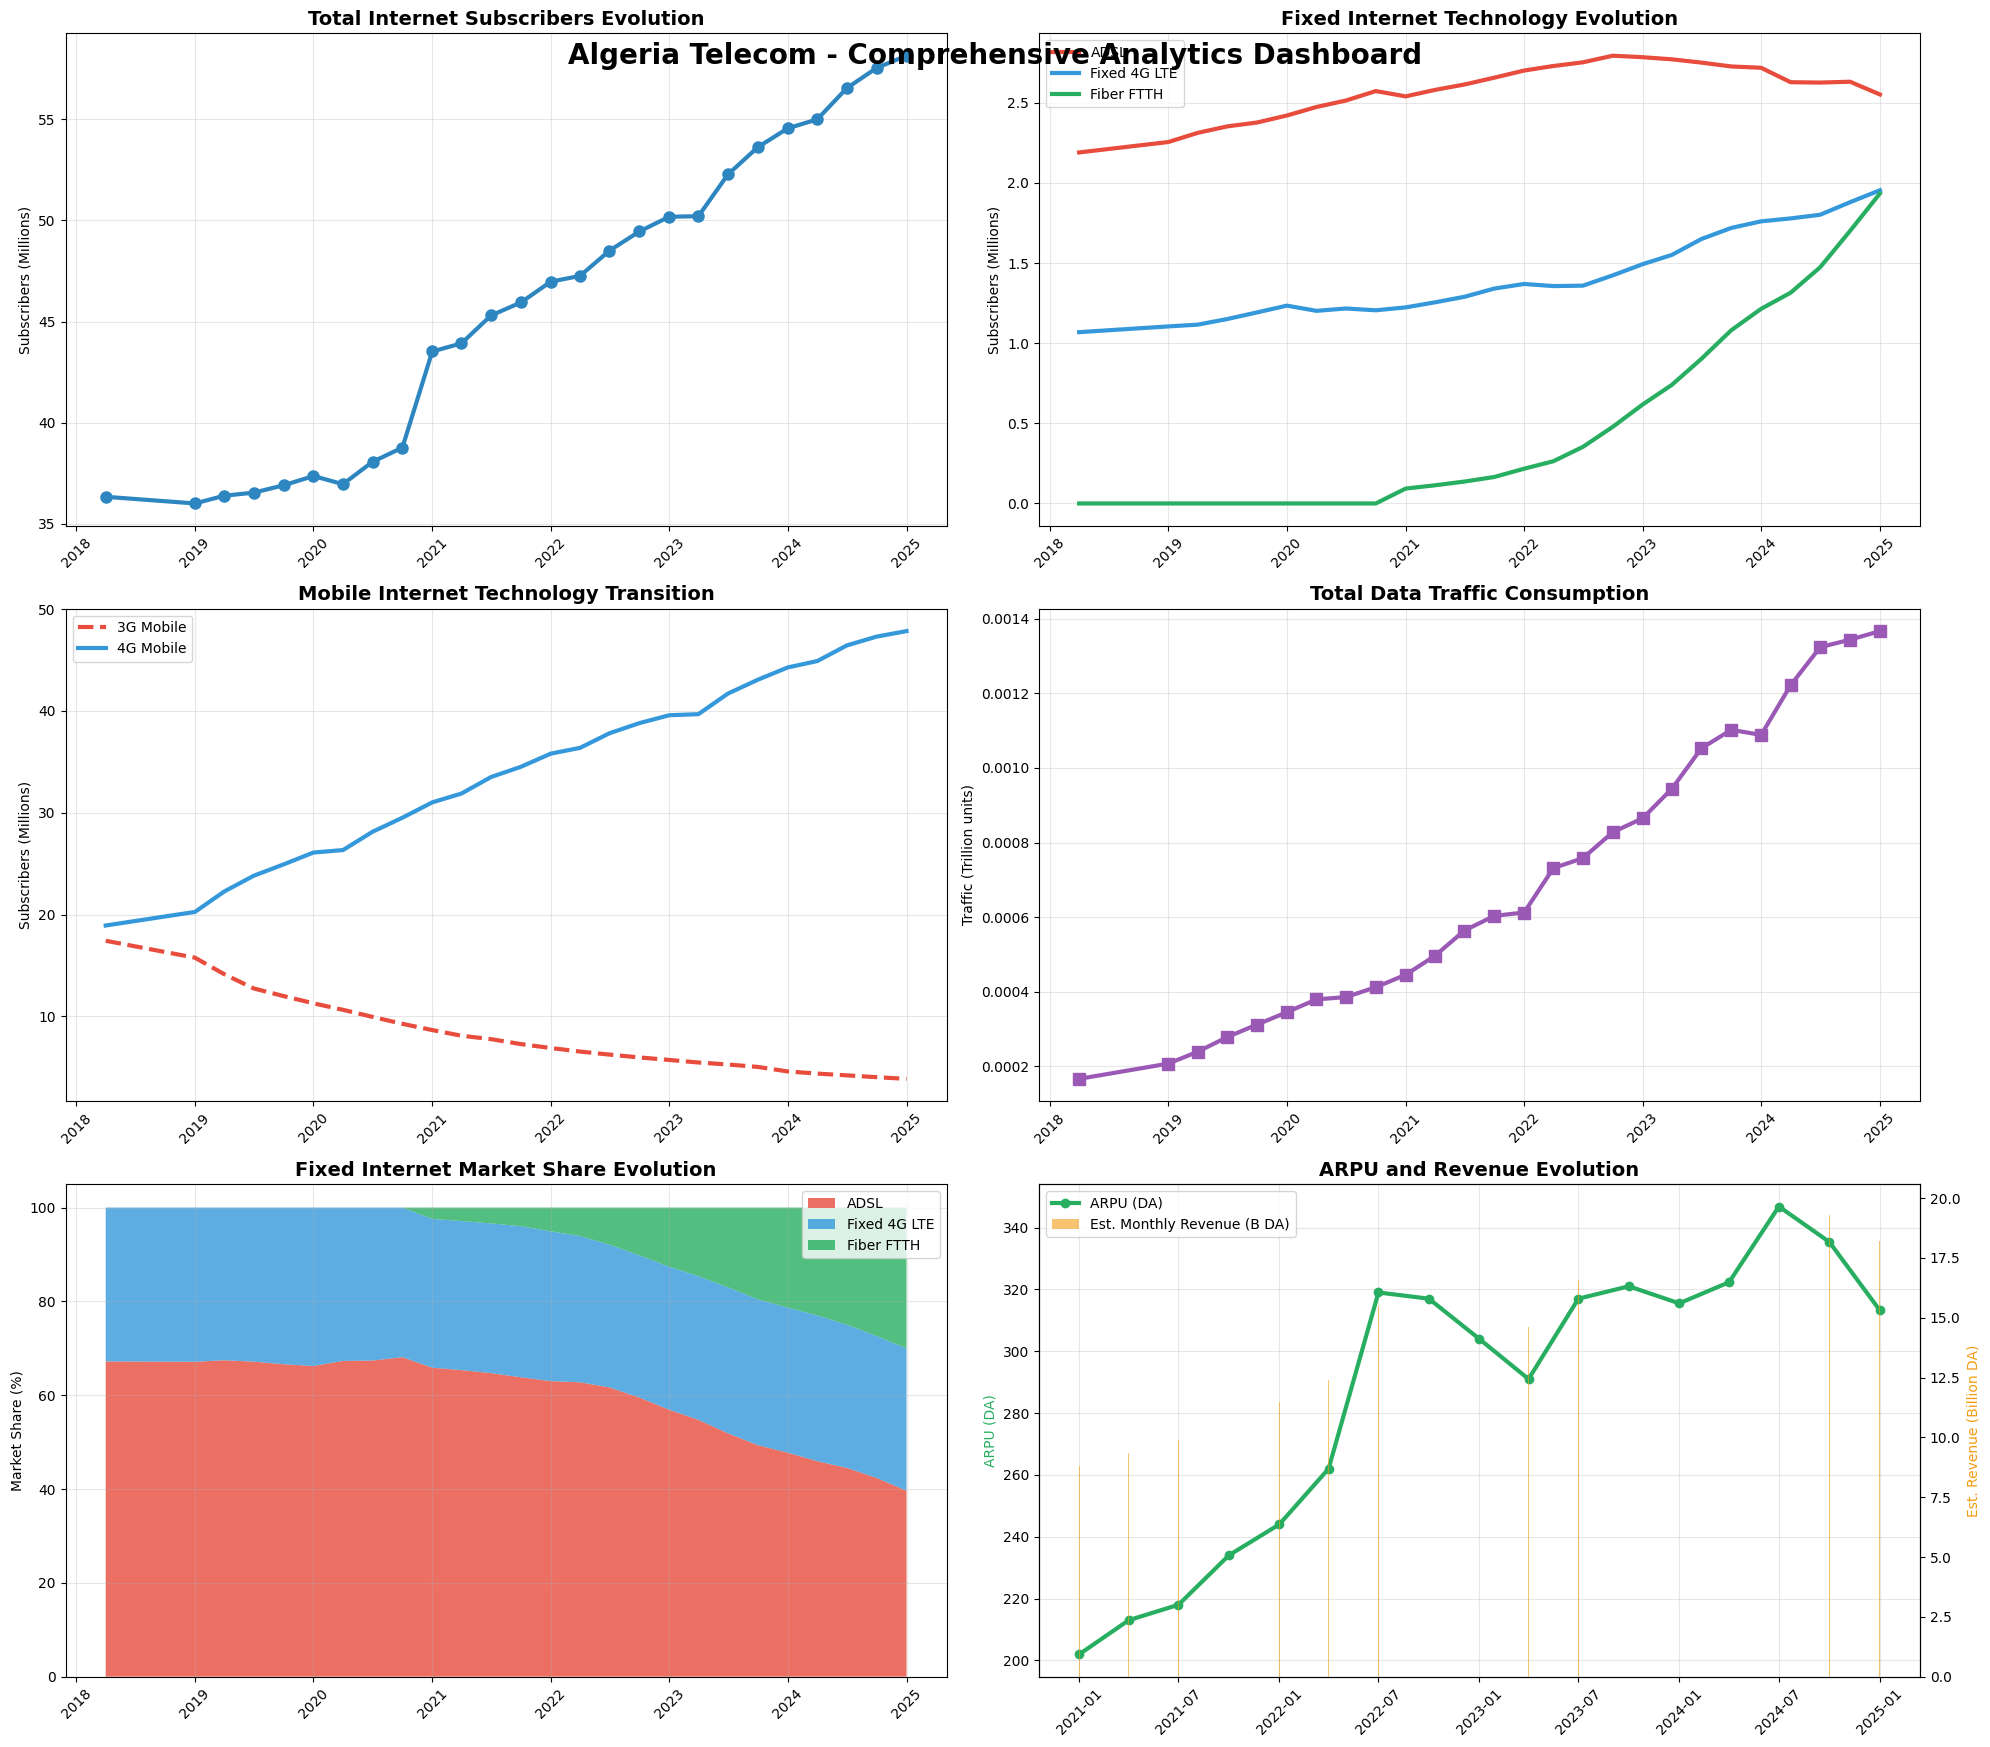

✅ Comprehensive dashboard created successfully!


In [ ]:
def create_comprehensive_dashboard(df):
    """Create comprehensive visualization dashboard"""

    print("📊 CREATING COMPREHENSIVE VISUALIZATION DASHBOARD")
    print("="*55)

    # Create main dashboard
    fig, axes = plt.subplots(3, 2, figsize=(20, 18))
    fig.suptitle('Algeria Telecom - Comprehensive Analytics Dashboard', fontsize=20, fontweight='bold', y=0.95)

    # 1. Total Internet Subscribers Evolution
    ax1 = axes[0, 0]
    ax1.plot(df['Date'], df['Total_Internet_Subscribers']/1e6, marker='o', linewidth=3, color='#2E86C1', markersize=8)
    ax1.set_title('Total Internet Subscribers Evolution', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Subscribers (Millions)')
    ax1.grid(True, alpha=0.3)
    ax1.tick_params(axis='x', rotation=45)

    # 2. Fixed Internet Technology Mix
    ax2 = axes[0, 1]
    ax2.plot(df['Date'], df['ADSL_Subscribers']/1e6, label='ADSL', linewidth=3, color='#E74C3C')
    ax2.plot(df['Date'], df['Fixed_4G_LTE_Subscribers']/1e6, label='Fixed 4G LTE', linewidth=3, color='#3498DB')
    fiber_data = df['Fiber_FTTH_Subscribers'].fillna(0)
    ax2.plot(df['Date'], fiber_data/1e6, label='Fiber FTTH', linewidth=3, color='#27AE60')
    ax2.set_title('Fixed Internet Technology Evolution', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Subscribers (Millions)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.tick_params(axis='x', rotation=45)

    # 3. Mobile Internet Technology Transition
    ax3 = axes[1, 0]
    ax3.plot(df['Date'], df['3G_Subscribers']/1e6, label='3G Mobile', linewidth=3, color='#E74C3C', linestyle='--')
    ax3.plot(df['Date'], df['4G_Subscribers']/1e6, label='4G Mobile', linewidth=3, color='#3498DB')
    ax3.set_title('Mobile Internet Technology Transition', fontsize=14, fontweight='bold')
    ax3.set_ylabel('Subscribers (Millions)')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    ax3.tick_params(axis='x', rotation=45)

    # 4. Data Traffic Consumption Growth
    ax4 = axes[1, 1]
    ax4.plot(df['Date'], df['Total_Traffic_Consumed']/1e12, marker='s', linewidth=3, color='#9B59B6', markersize=8)
    ax4.set_title('Total Data Traffic Consumption', fontsize=14, fontweight='bold')
    ax4.set_ylabel('Traffic (Trillion units)')
    ax4.grid(True, alpha=0.3)
    ax4.tick_params(axis='x', rotation=45)

    # 5. Market Share Evolution (Fixed Internet)
    ax5 = axes[2, 0]
    total_fixed = df['ADSL_Subscribers'] + df['Fixed_4G_LTE_Subscribers'] + df['Fiber_FTTH_Subscribers'].fillna(0)
    adsl_share = (df['ADSL_Subscribers'] / total_fixed * 100)
    fixed_4g_share = (df['Fixed_4G_LTE_Subscribers'] / total_fixed * 100)
    fiber_share = (df['Fiber_FTTH_Subscribers'].fillna(0) / total_fixed * 100)

    ax5.stackplot(df['Date'], adsl_share, fixed_4g_share, fiber_share,
                  labels=['ADSL', 'Fixed 4G LTE', 'Fiber FTTH'],
                  colors=['#E74C3C', '#3498DB', '#27AE60'], alpha=0.8)
    ax5.set_title('Fixed Internet Market Share Evolution', fontsize=14, fontweight='bold')
    ax5.set_ylabel('Market Share (%)')
    ax5.legend(loc='upper right')
    ax5.grid(True, alpha=0.3)
    ax5.tick_params(axis='x', rotation=45)

    # 6. ARPU and Revenue Analysis
    ax6 = axes[2, 1]
    arpu_data = df[df['Average_Revenue_Per_User_DA'].notna()]
    if len(arpu_data) > 0:
        ax6_twin = ax6.twinx()

        # ARPU line
        line1 = ax6.plot(arpu_data['Date'], arpu_data['Average_Revenue_Per_User_DA'],
                        marker='o', linewidth=3, color='#27AE60', label='ARPU (DA)')

        # Estimated revenue bars
        estimated_revenue = (arpu_data['Total_Internet_Subscribers'] * arpu_data['Average_Revenue_Per_User_DA']) / 1e9
        bars = ax6_twin.bar(arpu_data['Date'], estimated_revenue, alpha=0.6, color='#F39C12',
                           label='Est. Monthly Revenue (B DA)')

        ax6.set_ylabel('ARPU (DA)', color='#27AE60')
        ax6_twin.set_ylabel('Est. Revenue (Billion DA)', color='#F39C12')
        ax6.set_title('ARPU and Revenue Evolution', fontsize=14, fontweight='bold')

        # Combine legends
        lines1, labels1 = ax6.get_legend_handles_labels()
        lines2, labels2 = ax6_twin.get_legend_handles_labels()
        ax6.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
    else:
        ax6.text(0.5, 0.5, 'ARPU Data Not Available', ha='center', va='center', transform=ax6.transAxes)
        ax6.set_title('ARPU Analysis', fontsize=14, fontweight='bold')

    ax6.grid(True, alpha=0.3)
    ax6.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

    print("✅ Comprehensive dashboard created successfully!")

# Create dashboard
create_comprehensive_dashboard(df)

# **6. TOTAL INTERNET SUBSCRIBERS DEEP DIVE ANALYSIS**

📊 ANALYZING TOTAL INTERNET SUBSCRIBERS - COMPREHENSIVE ANALYSIS


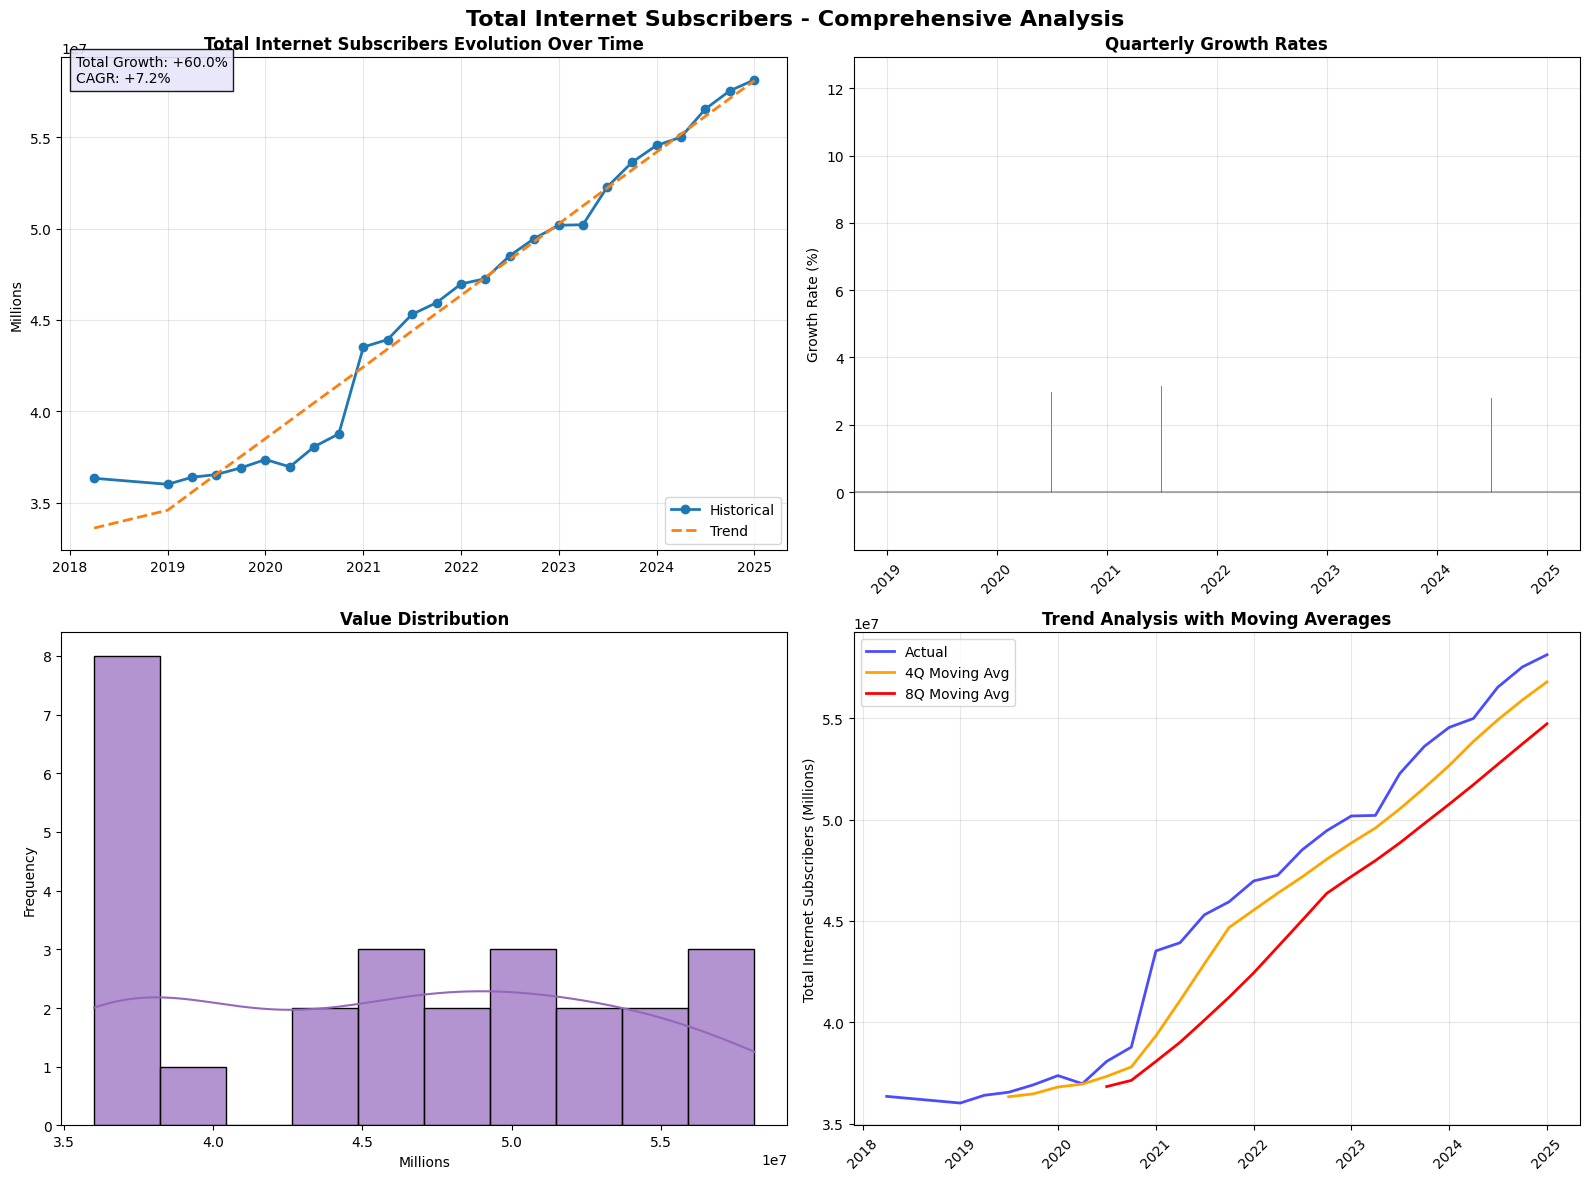


📈 Key Performance Indicators:
   • Current Value: 58,139,598.00 Millions
   • Peak Value: 58,139,598.00 Millions
   • Lowest Value: 36,013,224.00 Millions
   • Total Growth: +60.0%
   • CAGR: +7.20% per year
   • Average QoQ Growth: +1.92%
   • Volatility (Std Dev of QoQ Growth): 2.47%
   • Market Status: 📈 Stable Growth with Low Volatility


In [ ]:
def analyze_metric_deep_dive(df, metric_name, display_name, units=None):
    """Deep dive analysis with improved visuals + remarks"""

    print(f"📊 ANALYZING {display_name.upper()} - COMPREHENSIVE ANALYSIS")
    print("="*60)

    data = df[metric_name].fillna(0)

    # --- Auto-scaling units ---
    scale = 1
    if units is None:
        if "Subscribers" in metric_name:
            scale = 1e6
            units = "Millions"
        elif "Traffic" in metric_name:
            scale = 1e12
            units = "Trillion units"
        elif "Revenue" in metric_name or "ARPU" in metric_name:
            scale = 1e9
            units = "Billion DA"
        else:
            scale = 1
            units = "Units"

    # --- Key stats ---
    current_value = data.iloc[-1]
    peak_value = data.max()
    lowest_value = data.min()
    total_growth = ((current_value - data.iloc[0]) / data.iloc[0]) * 100
    years = (df['Date'].iloc[-1] - df['Date'].iloc[0]).days / 365.25
    cagr = ((current_value / data.iloc[0]) ** (1/years) - 1) * 100 if years > 0 else 0
    qoq_growth = data.pct_change() * 100
    avg_qoq_growth = qoq_growth.mean()
    volatility = qoq_growth.std()

    # --- Figure setup ---
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f'{display_name} - Comprehensive Analysis', fontsize=16, fontweight='bold')

    # 1. Time Series + Trend (new improved)
    axes[0,0].plot(df['Date'], data/scale, marker='o', color='#1f77b4', linewidth=2, label='Historical')
    z = np.polyfit(range(len(data)), data, 1)
    p = np.poly1d(z)
    axes[0,0].plot(df['Date'], p(range(len(data)))/scale, linestyle='--', color='#ff7f0e', linewidth=2, label='Trend')
    axes[0,0].set_title(f'{display_name} Evolution Over Time', fontsize=12, fontweight='bold')
    axes[0,0].set_ylabel(units)
    axes[0,0].grid(True, alpha=0.3)
    axes[0,0].legend()
    axes[0,0].text(0.02, 0.95, f'Total Growth: {total_growth:+.1f}%\nCAGR: {cagr:+.1f}%',
                   transform=axes[0,0].transAxes, fontsize=10,
                   bbox=dict(facecolor='lavender', alpha=0.9))

    # 2. Growth Rate Analysis
    colors = ['green' if x >= 0 else 'red' for x in qoq_growth]
    axes[0, 1].bar(df['Date'][1:], qoq_growth[1:], color=colors, alpha=0.7)
    axes[0, 1].axhline(y=0, color='black', linestyle='-', alpha=0.3)
    axes[0, 1].set_title('Quarterly Growth Rates', fontsize=12, fontweight='bold')
    axes[0, 1].set_ylabel('Growth Rate (%)')
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].tick_params(axis='x', rotation=45)

    # 3. Histogram with KDE
    sns.histplot(data/scale, bins=10, kde=True, ax=axes[1,0], color='#9467bd', alpha=0.7)
    axes[1,0].set_title('Value Distribution', fontsize=12, fontweight='bold')
    axes[1,0].set_xlabel(units)
    axes[1,0].set_ylabel('Frequency')

    # 4. Moving Averages and Trend
    ma_4 = data.rolling(window=4).mean()
    ma_8 = data.rolling(window=8).mean()
    axes[1, 1].plot(df['Date'], data/scale,
                    label='Actual', linewidth=2, color='blue', alpha=0.7)
    axes[1, 1].plot(df['Date'], ma_4/scale,
                    label='4Q Moving Avg', linewidth=2, color='orange')
    if len(data) >= 8:
        axes[1, 1].plot(df['Date'], ma_8/scale,
                        label='8Q Moving Avg', linewidth=2, color='red')
    axes[1, 1].set_title('Trend Analysis with Moving Averages', fontsize=12, fontweight='bold')
    axes[1, 1].set_ylabel(f'{display_name} ({units})')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

    # --- Analytical Remarks ---
    print("\n📈 Key Performance Indicators:")
    print(f"   • Current Value: {current_value/scale:,.2f} {units}")
    print(f"   • Peak Value: {peak_value/scale:,.2f} {units}")
    print(f"   • Lowest Value: {lowest_value/scale:,.2f} {units}")
    print(f"   • Total Growth: {total_growth:+.1f}%")
    print(f"   • CAGR: {cagr:+.2f}% per year")
    print(f"   • Average QoQ Growth: {avg_qoq_growth:+.2f}%")
    print(f"   • Volatility (Std Dev of QoQ Growth): {volatility:.2f}%")

    if avg_qoq_growth > 0 and volatility < 3:
        print("   • Market Status: 📈 Stable Growth with Low Volatility")
    elif avg_qoq_growth > 0 and volatility >= 3:
        print("   • Market Status: ⚡ Growth with High Volatility (unstable)")
    elif avg_qoq_growth <= 0:
        print("   • Market Status: 📉 Declining / Stagnating")

total_subscribers_analysis = analyze_metric_deep_dive(df, 'Total_Internet_Subscribers', 'Total Internet Subscribers', 'Millions')

## **6.1 Analyze ADSL Subscribers**

📊 ANALYZING ADSL SUBSCRIBERS - COMPREHENSIVE ANALYSIS


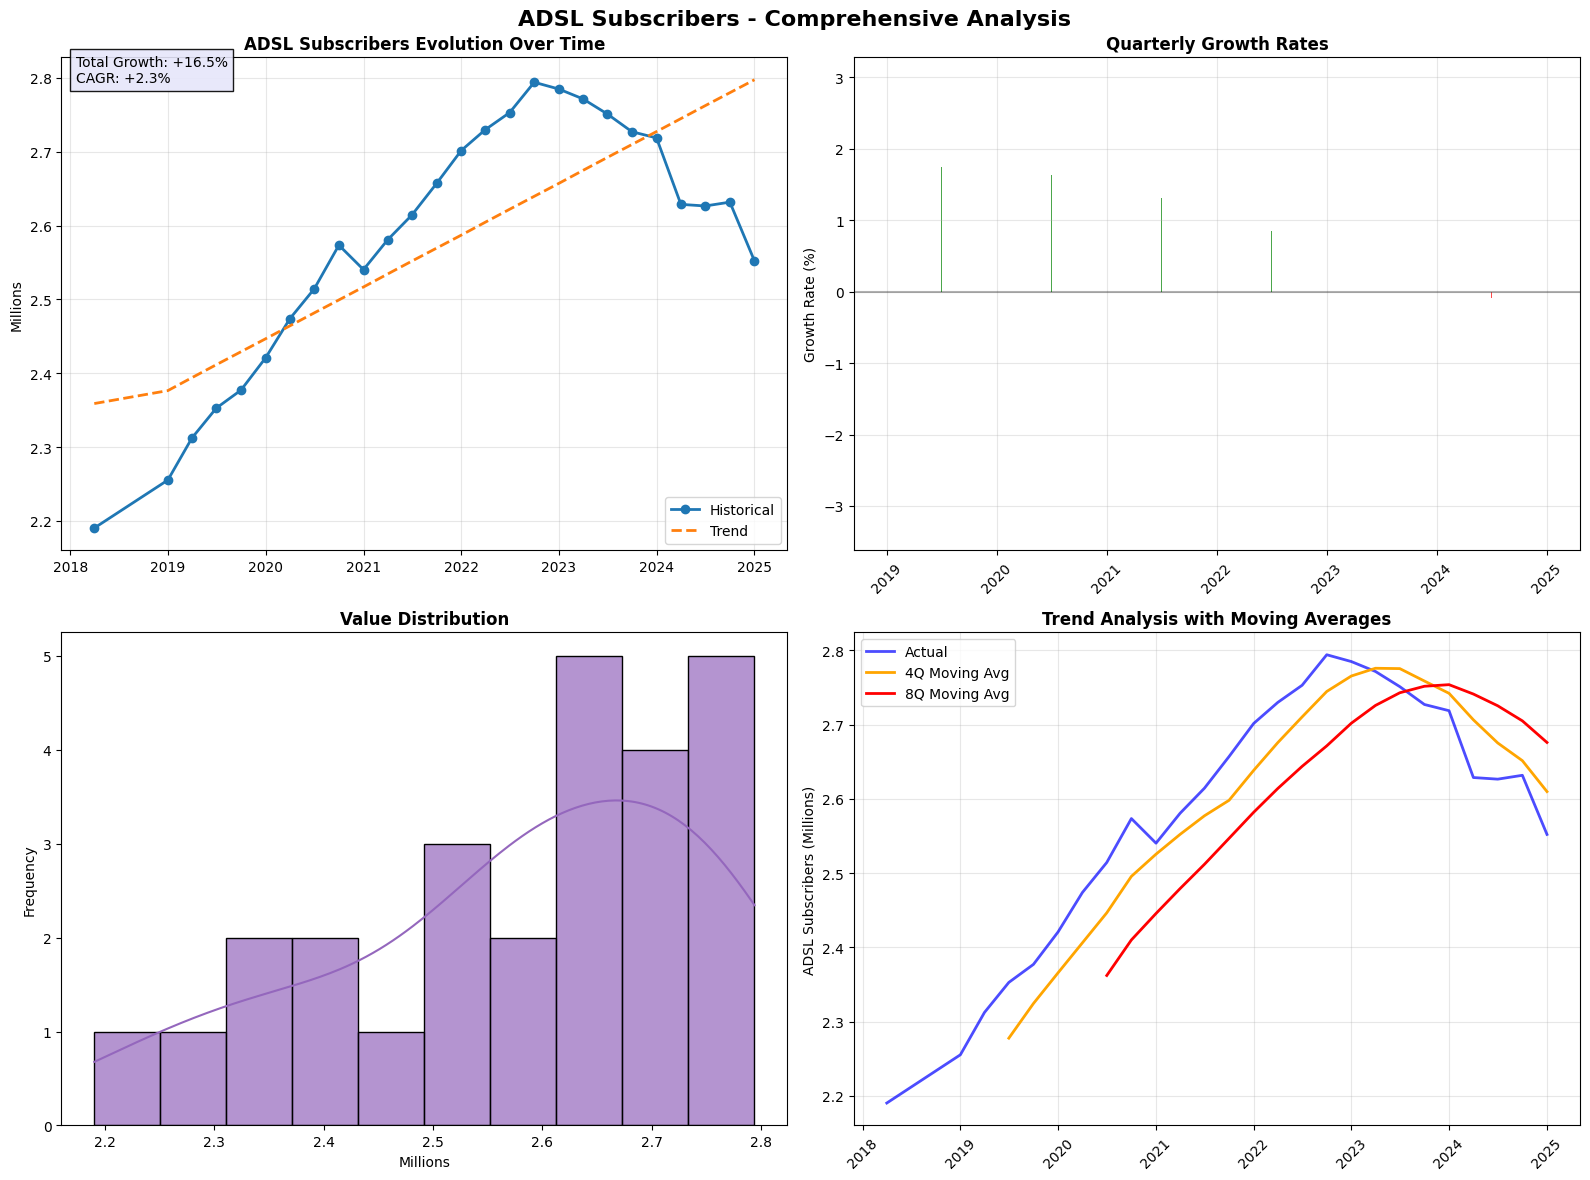


📈 Key Performance Indicators:
   • Current Value: 2.55 Millions
   • Peak Value: 2.79 Millions
   • Lowest Value: 2.19 Millions
   • Total Growth: +16.5%
   • CAGR: +2.29% per year
   • Average QoQ Growth: +0.63%
   • Volatility (Std Dev of QoQ Growth): 1.62%
   • Market Status: 📈 Stable Growth with Low Volatility


In [ ]:
adsl_analysis = analyze_metric_deep_dive(df, 'ADSL_Subscribers', 'ADSL Subscribers')

## **6.2 Analyze Fiber FTTH Subscribers**



📊 ANALYZING FIBER FTTH SUBSCRIBERS - COMPREHENSIVE ANALYSIS


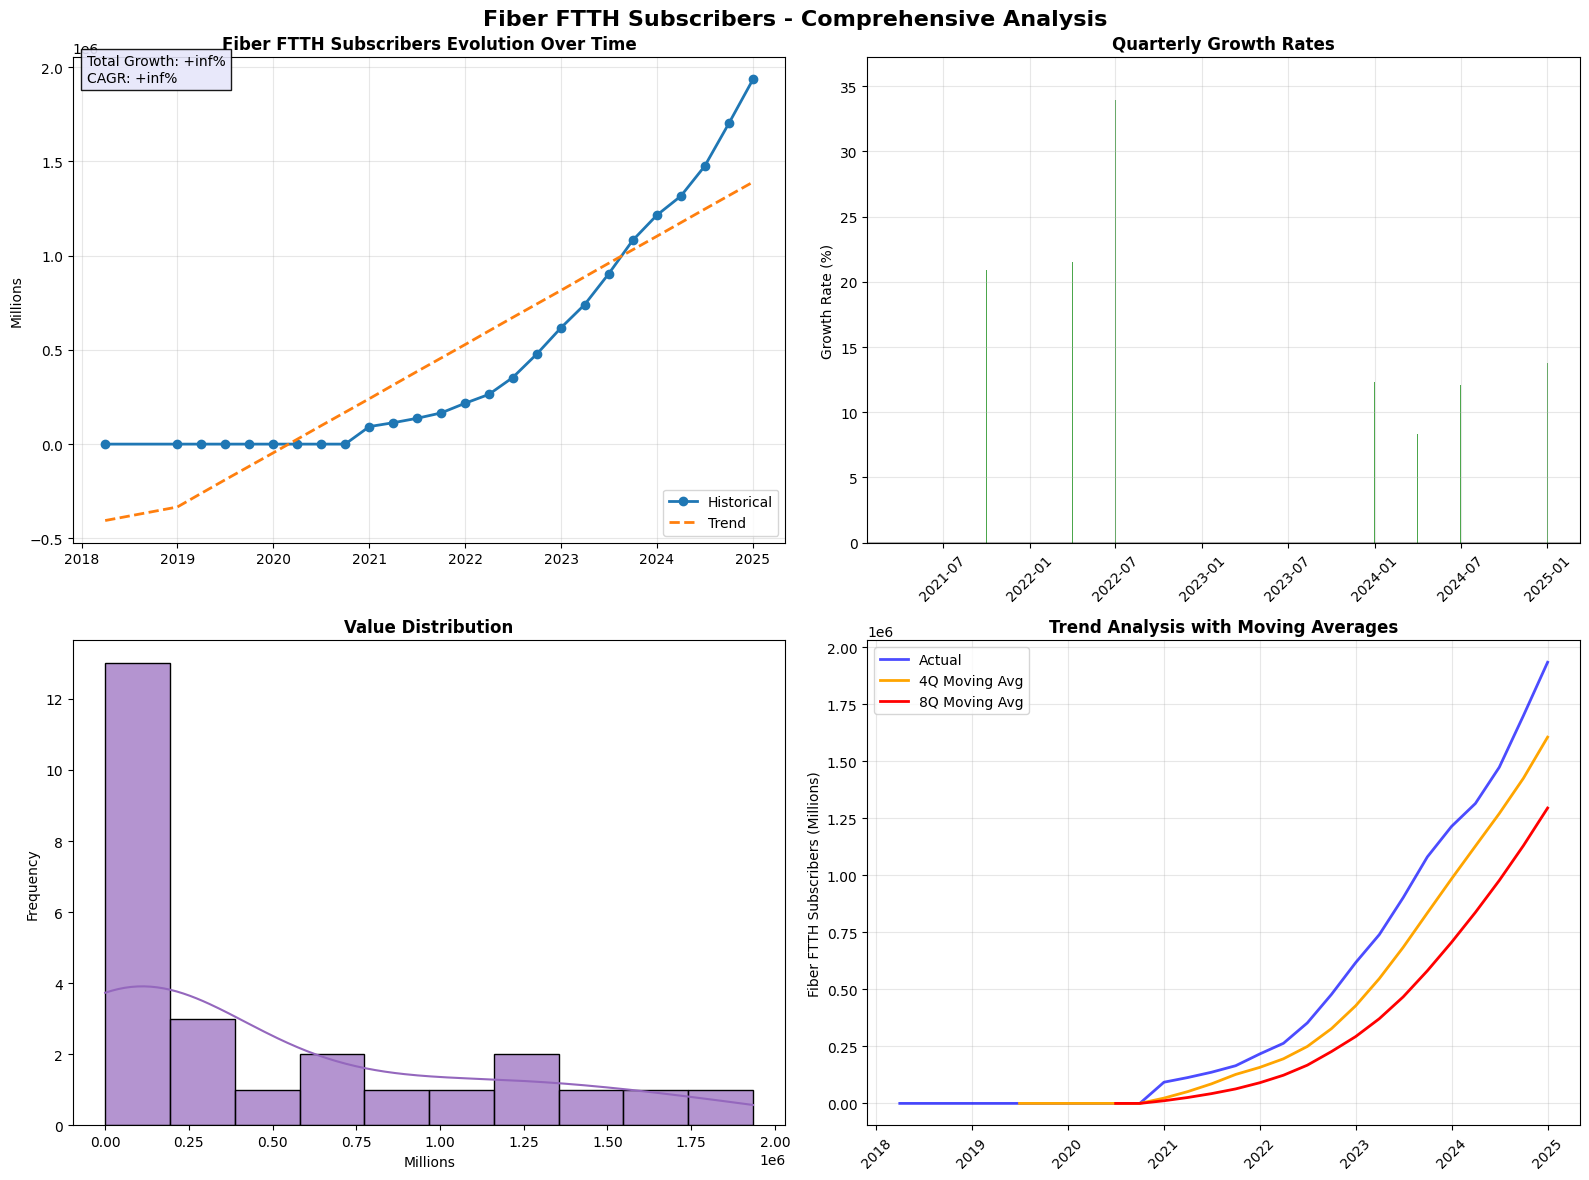


📈 Key Performance Indicators:
   • Current Value: 1,934,620.00 Millions
   • Peak Value: 1,934,620.00 Millions
   • Lowest Value: 0.00 Millions
   • Total Growth: +inf%
   • CAGR: +inf% per year
   • Average QoQ Growth: +inf%
   • Volatility (Std Dev of QoQ Growth): nan%


In [ ]:
fiber_analysis = analyze_metric_deep_dive(df, 'Fiber_FTTH_Subscribers', 'Fiber FTTH Subscribers', 'Millions')

## **6.3 Analyze Total Traffic Consumed**

📊 ANALYZING TOTAL DATA TRAFFIC CONSUMED - COMPREHENSIVE ANALYSIS


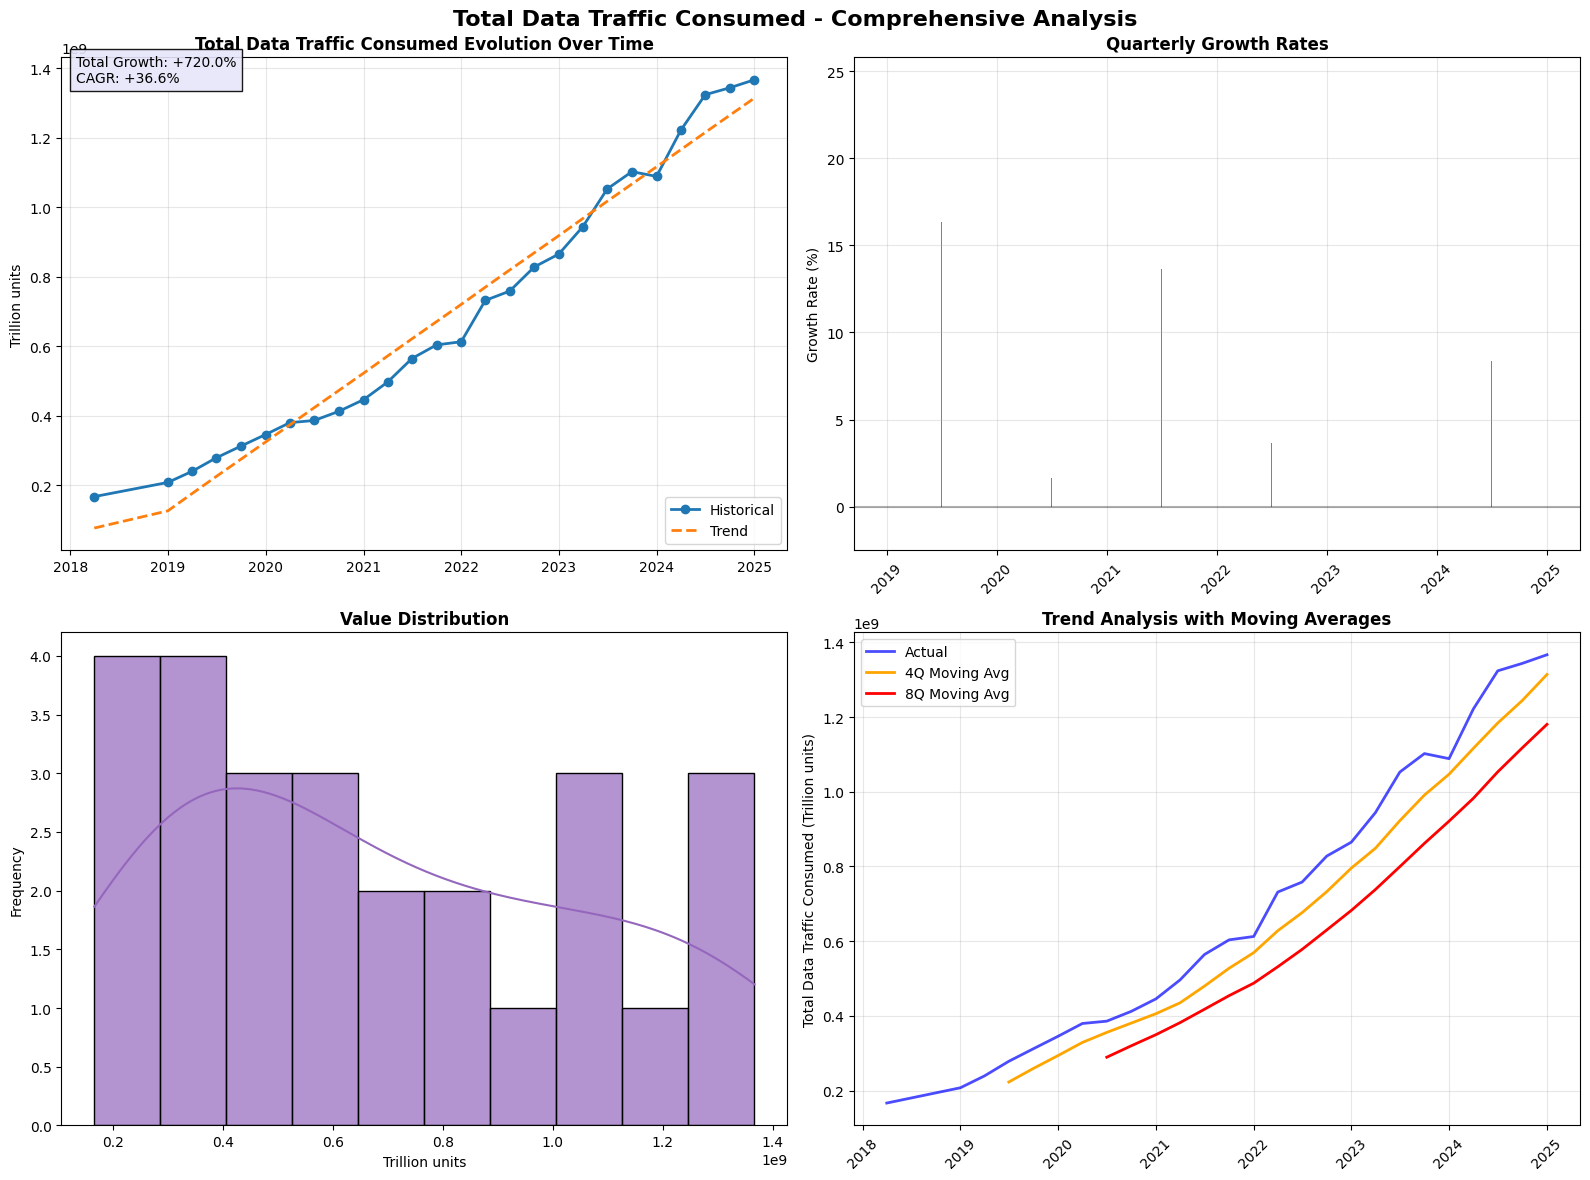


📈 Key Performance Indicators:
   • Current Value: 1,366,893,341.00 Trillion units
   • Peak Value: 1,366,893,341.00 Trillion units
   • Lowest Value: 166,691,345.00 Trillion units
   • Total Growth: +720.0%
   • CAGR: +36.55% per year
   • Average QoQ Growth: +8.94%
   • Volatility (Std Dev of QoQ Growth): 6.13%
   • Market Status: ⚡ Growth with High Volatility (unstable)


In [ ]:
traffic_analysis = analyze_metric_deep_dive(df, 'Total_Traffic_Consumed', 'Total Data Traffic Consumed', 'Trillion units')

## **6.4 Analyze Total Traffic Consumed**

📊 ANALYZING 4G MOBILE SUBSCRIBERS - COMPREHENSIVE ANALYSIS


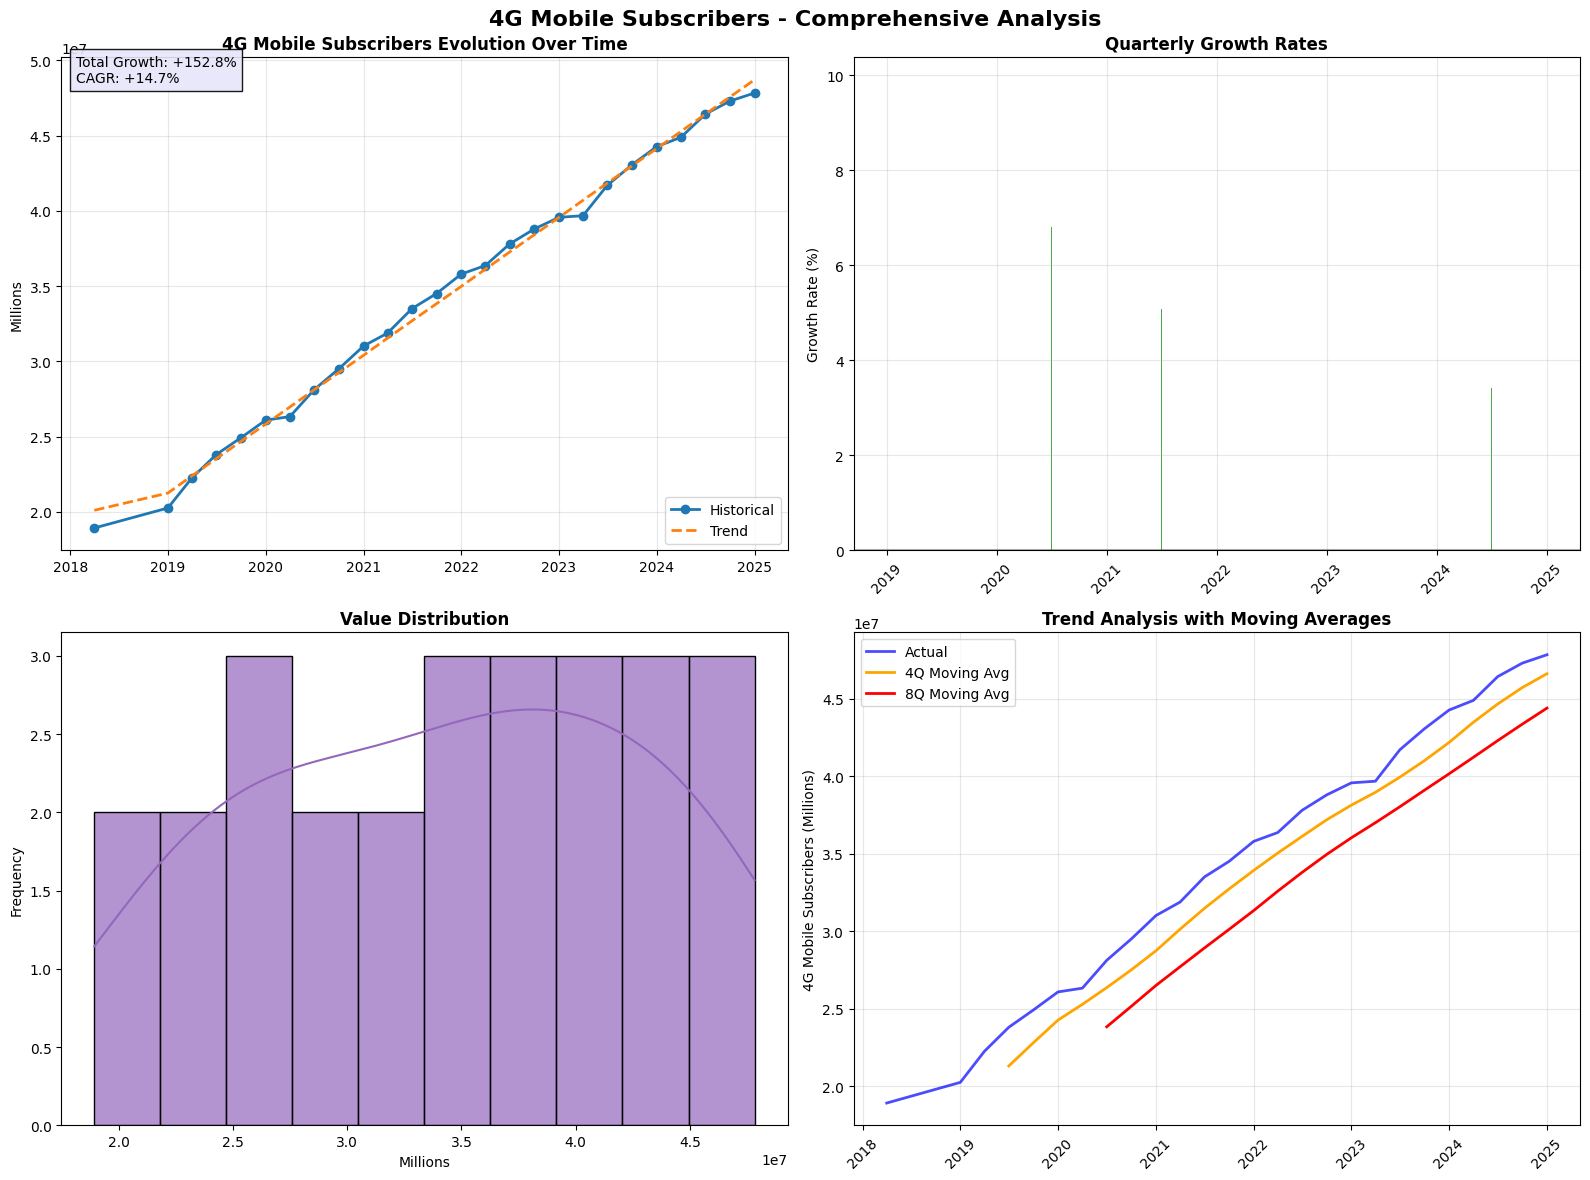


📈 Key Performance Indicators:
   • Current Value: 47,836,371.00 Millions
   • Peak Value: 47,836,371.00 Millions
   • Lowest Value: 18,920,289.00 Millions
   • Total Growth: +152.8%
   • CAGR: +14.72% per year
   • Average QoQ Growth: +3.80%
   • Volatility (Std Dev of QoQ Growth): 2.28%
   • Market Status: 📈 Stable Growth with Low Volatility


In [ ]:
mobile_4g_analysis = analyze_metric_deep_dive(df, '4G_Subscribers', '4G Mobile Subscribers', 'Millions')

# **7. BASIC FORECASTING FOR KEY METRICS**

  BASIC FORECASTING DASHBOARD

📊 Forecasting Total Subscribers...
   ✅ Total Subscribers: +13.9% growth expected

📊 Forecasting Fiber FTTH...
   ✅ Fiber FTTH: +100.2% growth expected

📊 Forecasting Data Traffic...
   ✅ Data Traffic: +38.1% growth expected

📊 Forecasting 4G Mobile...
   ✅ 4G Mobile: +14.6% growth expected


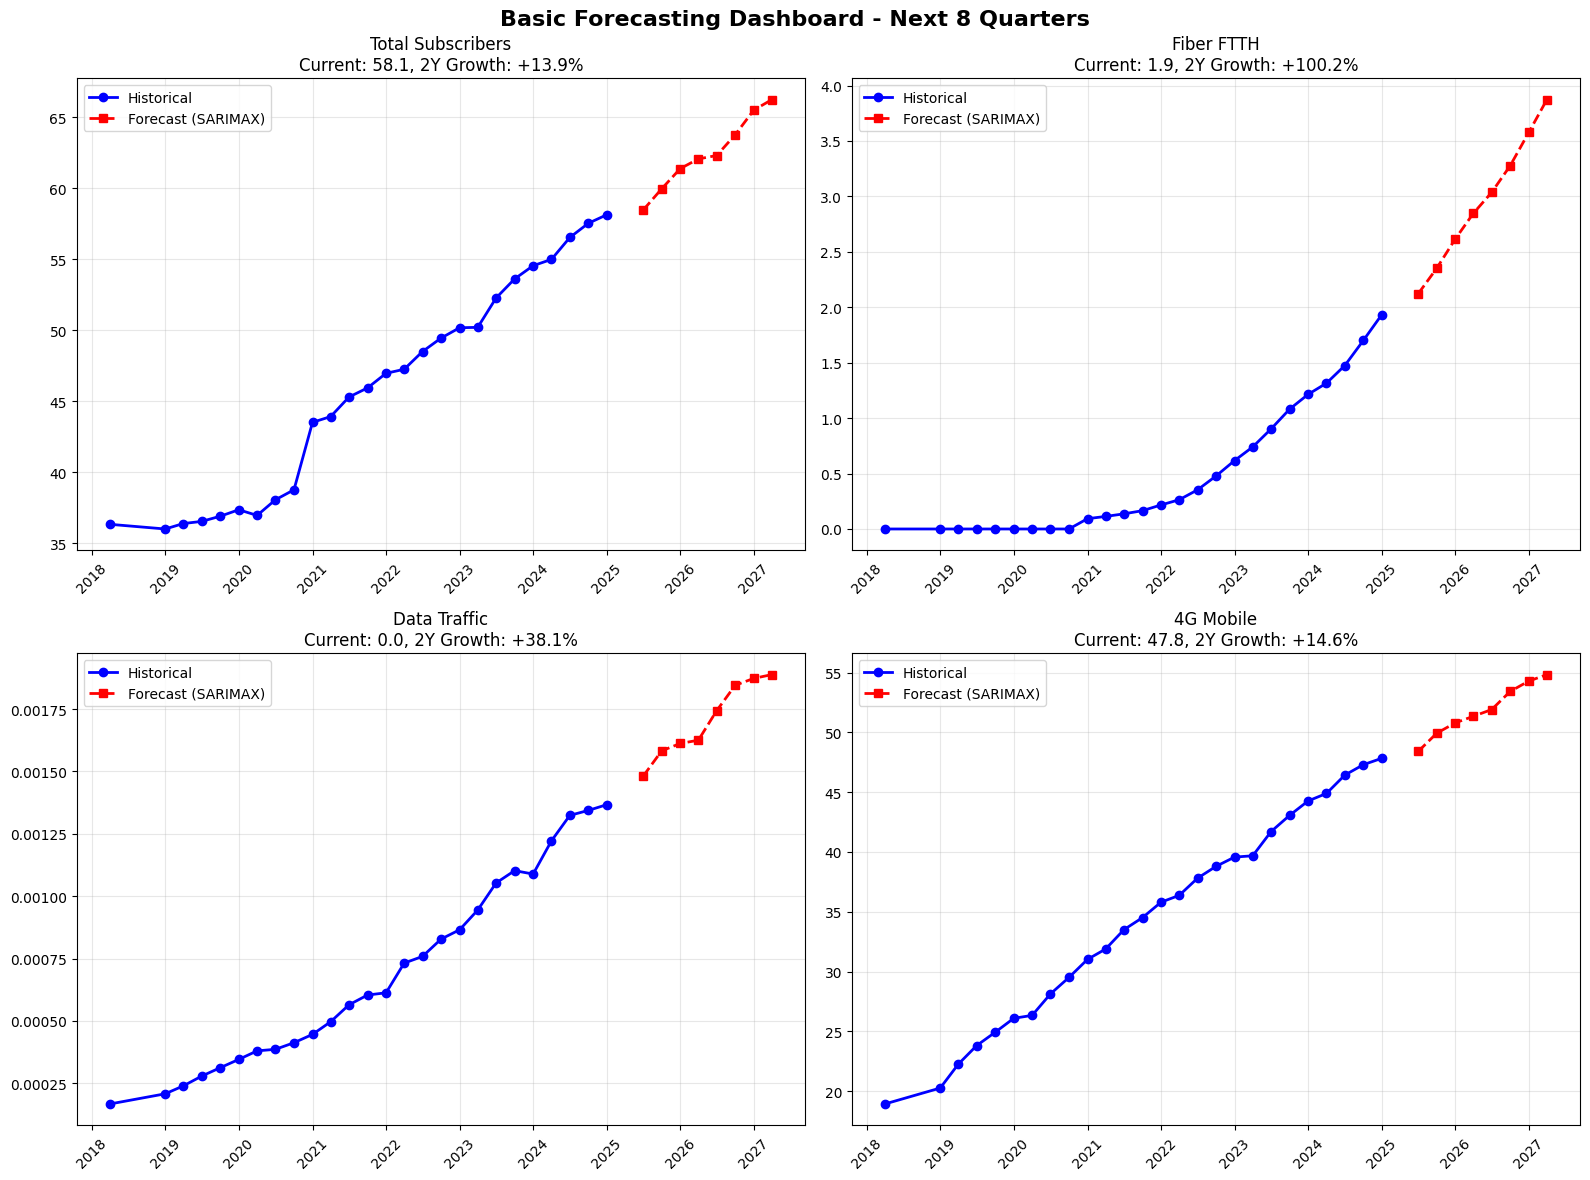

In [ ]:
def basic_forecasting_dashboard(df):
    """Basic forecasting for key metrics with 4 plots (2x2) - no pmdarima dependency"""

    print("  BASIC FORECASTING DASHBOARD")
    print("="*40)

    # Key metrics to forecast
    forecast_metrics = {
        'Total_Internet_Subscribers': 'Total Subscribers',
        'Fiber_FTTH_Subscribers': 'Fiber FTTH',
        'Total_Traffic_Consumed': 'Data Traffic',
        '4G_Subscribers': '4G Mobile'
    }

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Basic Forecasting Dashboard - Next 8 Quarters', fontsize=16, fontweight='bold')

    axes_flat = axes.flatten()

    for idx, (metric, display_name) in enumerate(forecast_metrics.items()):
        ax = axes_flat[idx]

        print(f"\n📊 Forecasting {display_name}...")

        # Prepare data
        data = df[metric].fillna(0) if metric == 'Fiber_FTTH_Subscribers' else df[metric]

        try:
            # Try SARIMAX forecasting
            sarimax_model = SARIMAX(data, order=(1,1,1), seasonal_order=(1,1,1,4)).fit(disp=False)
            forecast = sarimax_model.forecast(steps=8)
            method = "SARIMAX"

            # Create future dates
            future_dates = pd.date_range(start=df['Date'].iloc[-1] + pd.DateOffset(months=3),
                                       periods=8, freq='Q')

            # Plot historical data
            scale_factor = 1e6 if 'Subscribers' in metric else 1e12
            ax.plot(df['Date'], data/scale_factor, marker='o', linewidth=2,
                   label='Historical', color='blue')

            # Plot forecast
            ax.plot(future_dates, forecast/scale_factor, marker='s', linewidth=2,
                   label=f'Forecast ({method})', color='red', linestyle='--')

            # Calculate growth
            current_value = data.iloc[-1]
            forecast_2_years = forecast.iloc[-1]
            growth = ((forecast_2_years - current_value) / current_value * 100)

            ax.set_title(f'{display_name}\nCurrent: {current_value/scale_factor:.1f}, 2Y Growth: {growth:+.1f}%')
            ax.legend()
            ax.grid(True, alpha=0.3)
            ax.tick_params(axis='x', rotation=45)

            print(f"   ✅ {display_name}: {growth:+.1f}% growth expected")

        except Exception as e:
            ax.text(0.5, 0.5, f'Forecasting failed\n{str(e)[:50]}...',
                   ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'{display_name} - Forecast Error')
            print(f"   ❌ {display_name}: Forecasting failed ({str(e)})")

    plt.tight_layout()
    plt.show()

# Run basic forecasting
basic_forecasting_dashboard(df)

# **8. ADVANCED TIME SERIES FORECASTING - TOTAL INTERNET SUBSCRIBERS**

 ADVANCED TIME SERIES FORECASTING: TOTAL INTERNET SUBSCRIBERS
📊 Data Overview:
   • Data points: 26
   • Time span: 2018-04 to 2025-01

📈 Statistical Analysis:
   • ADF Test p-value: 0.8105 (Non-stationary)


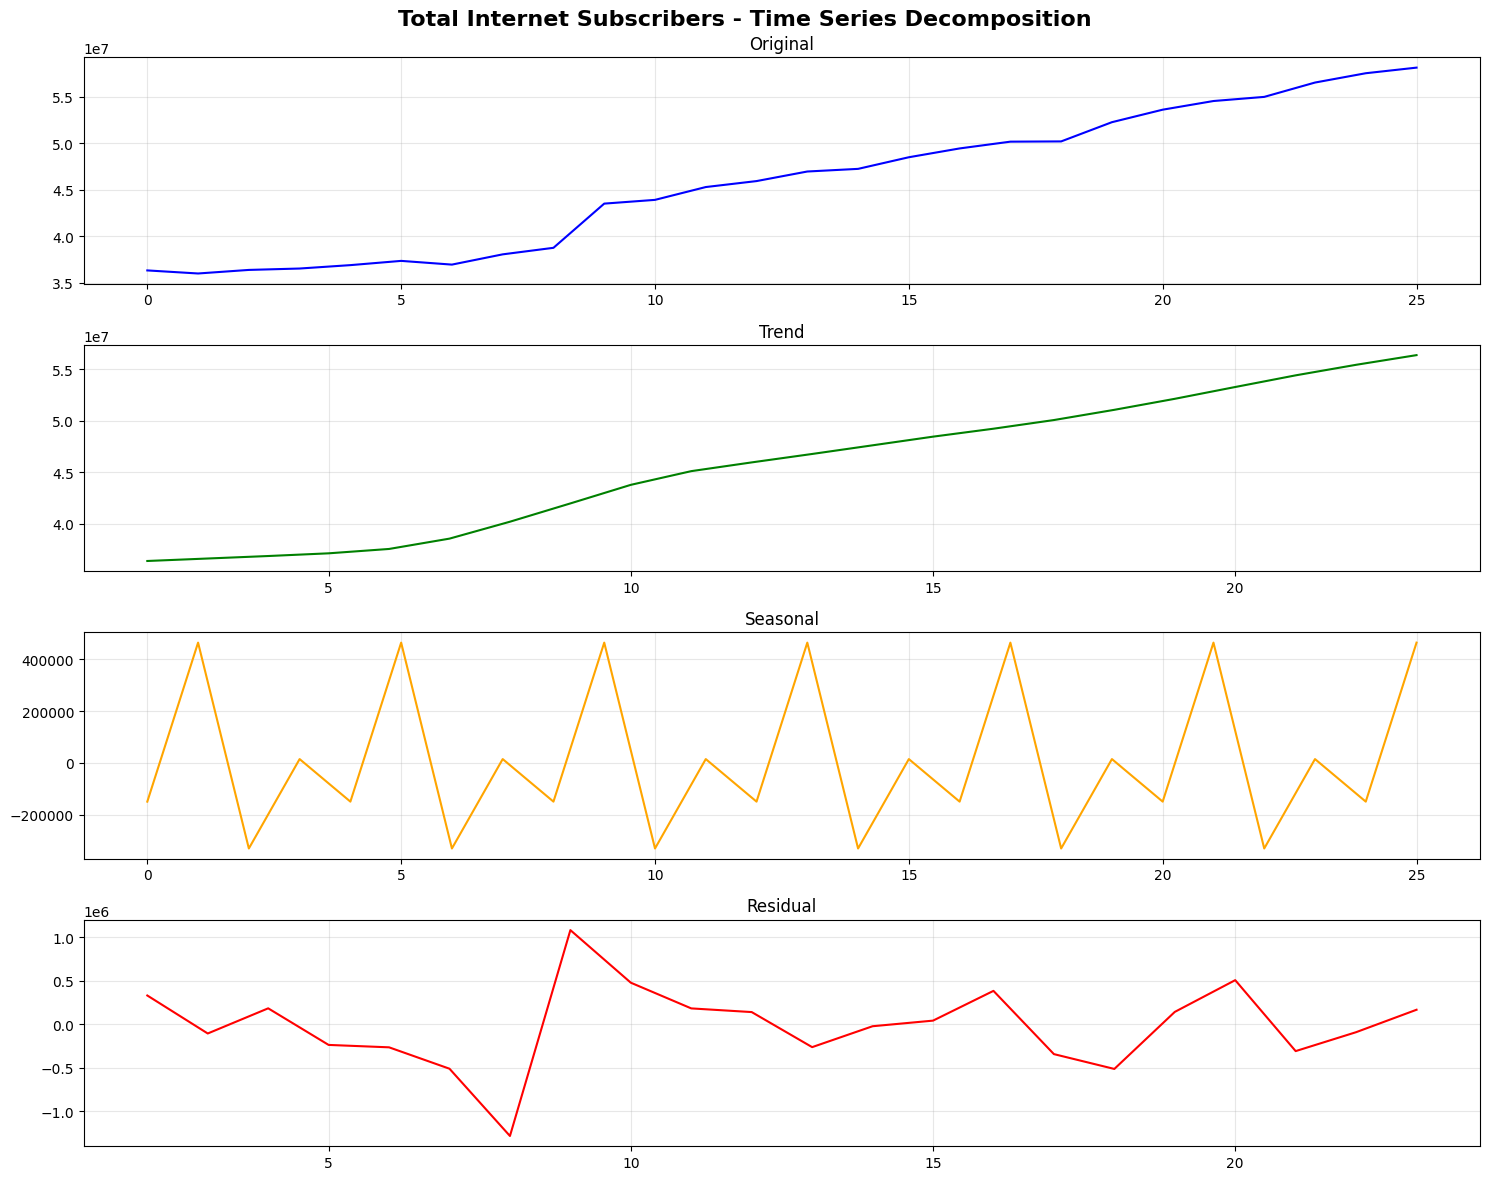

   • Seasonal Strength: 0.303

 Training Multiple Forecasting Models:
   ❌ ARIMA Model failed: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject
   ✅ Exponential Smoothing: MAE = 3676388.86
   ✅ Neural Network (LSTM): MAE = 638295.19
   ✅ XGBoost: MAE = 2780004.75

 Model Performance Comparison:
   🥇 Neural Network: MAE = 638295.19
   🥈 XGBoost: MAE = 2780004.75
   🥉 Exponential Smoothing: MAE = 3676388.86

✅ Best Model: Neural Network

🔮 Future Forecasting (Next 8 quarters):
   📊 Current Value: 58139598
   📈 2-Year Forecast: 65928024
   📊 Expected Growth: +13.4%


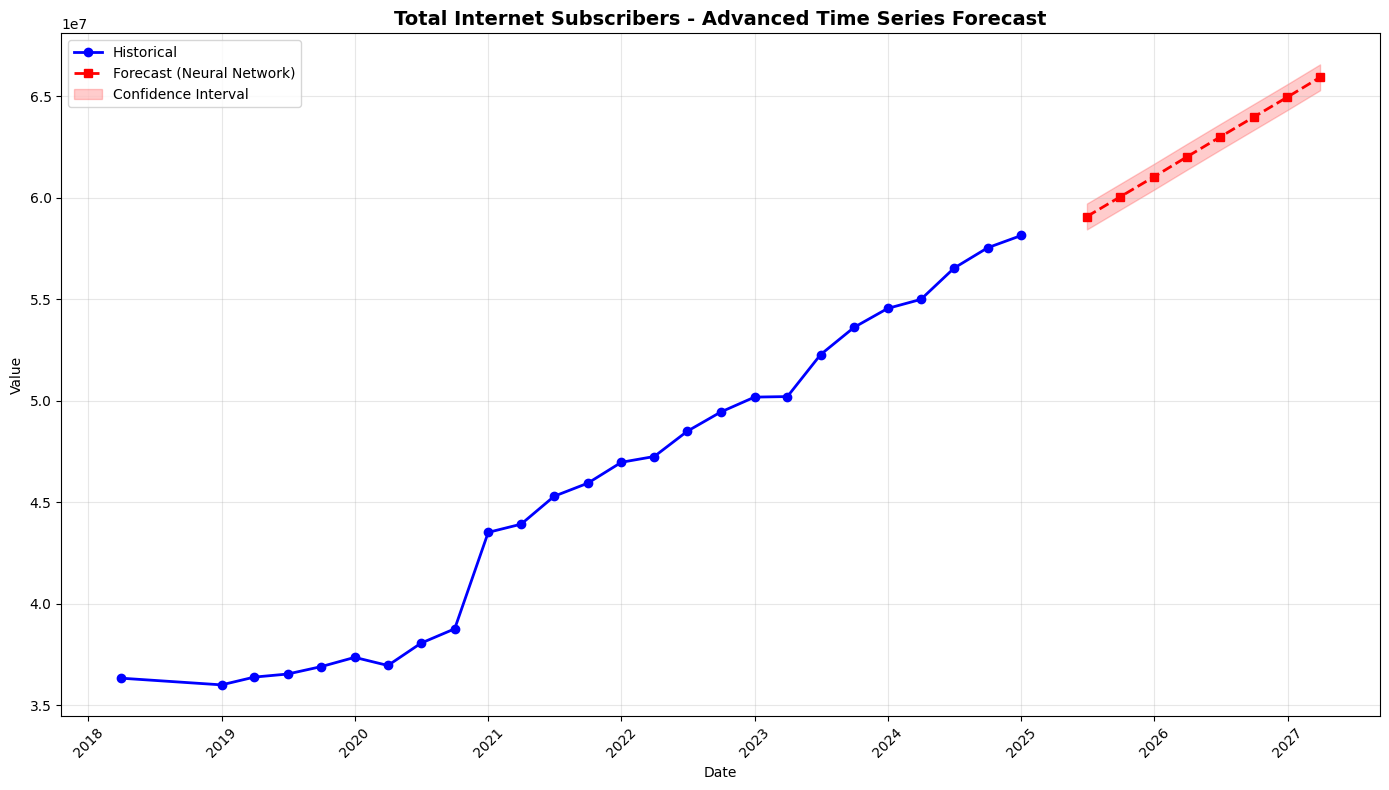

In [ ]:
def advanced_time_series_analysis_single(df, metric_name, display_name):
    """Advanced time series analysis for a single metric"""

    print(f" ADVANCED TIME SERIES FORECASTING: {display_name.upper()}")
    print("="*70)

    # Prepare data
    data = df[metric_name].fillna(0) if metric_name == 'Fiber_FTTH_Subscribers' else df[metric_name]

    print(f"📊 Data Overview:")
    print(f"   • Data points: {len(data)}")
    print(f"   • Time span: {df['Date'].min().strftime('%Y-%m')} to {df['Date'].max().strftime('%Y-%m')}")

    # Statistical Analysis
    print(f"\n📈 Statistical Analysis:")

    # ADF Test for stationarity
    adf_stat, adf_pvalue, _, _, adf_critical, _ = adfuller(data)
    stationarity_status = 'Stationary' if adf_pvalue < 0.05 else 'Non-stationary'
    print(f"   • ADF Test p-value: {adf_pvalue:.4f} ({stationarity_status})")

    # Seasonal decomposition
    if len(data) >= 8:  # Need at least 2 cycles for quarterly data
        try:
            decomposition = seasonal_decompose(data, model='additive', period=4)

            fig, axes = plt.subplots(4, 1, figsize=(15, 12))
            fig.suptitle(f'{display_name} - Time Series Decomposition', fontsize=16, fontweight='bold')

            decomposition.observed.plot(ax=axes[0], title='Original', color='blue')
            decomposition.trend.plot(ax=axes[1], title='Trend', color='green')
            decomposition.seasonal.plot(ax=axes[2], title='Seasonal', color='orange')
            decomposition.resid.plot(ax=axes[3], title='Residual', color='red')

            for ax in axes:
                ax.grid(True, alpha=0.3)

            plt.tight_layout()
            plt.show()

            # Calculate seasonal strength
            seasonal_strength = np.var(decomposition.seasonal) / np.var(decomposition.resid + decomposition.seasonal)
            print(f"   • Seasonal Strength: {seasonal_strength:.3f}")

        except Exception as e:
            print(f"   • Decomposition failed: {str(e)}")

    # Training Multiple Forecasting Models
    print(f"\n Training Multiple Forecasting Models:")

    # Split data for validation
    train_size = int(len(data) * 0.8)
    train_data = data[:train_size]
    test_data = data[train_size:]

    models_performance = {}
    forecasts = {}

    # Model 1: ARIMA
    try:
        from pmdarima import auto_arima
        arima_model = auto_arima(train_data, seasonal=True, m=4,
                               suppress_warnings=True, stepwise=True)
        arima_forecast = arima_model.predict(n_periods=len(test_data))
        arima_mae = mean_absolute_error(test_data, arima_forecast)

        models_performance['ARIMA'] = arima_mae
        forecasts['ARIMA'] = arima_forecast

        print(f"   ✅ ARIMA Model: MAE = {arima_mae:.2f}")

    except Exception as e:
        print(f"   ❌ ARIMA Model failed: {str(e)}")

    # Model 2: Exponential Smoothing
    try:
        exp_smooth = ExponentialSmoothing(train_data, seasonal='add', seasonal_periods=4).fit()
        exp_forecast = exp_smooth.forecast(len(test_data))
        exp_mae = mean_absolute_error(test_data, exp_forecast)

        models_performance['Exponential Smoothing'] = exp_mae
        forecasts['Exponential Smoothing'] = exp_forecast

        print(f"   ✅ Exponential Smoothing: MAE = {exp_mae:.2f}")

    except Exception as e:
        print(f"   ❌ Exponential Smoothing failed: {str(e)}")

    # Model 3: Neural Network (LSTM)
    try:
        # Scale data
        scaler = MinMaxScaler()
        scaled_data = scaler.fit_transform(data.values.reshape(-1, 1)).flatten()

        # Create sequences
        def create_sequences(data, seq_length=4):
            X, y = [], []
            for i in range(len(data) - seq_length):
                X.append(data[i:(i + seq_length)])
                y.append(data[i + seq_length])
            return np.array(X), np.array(y)

        X, y = create_sequences(scaled_data, seq_length=4)

        if len(X) > 10:  # Minimum data for neural network
            # Split for training
            train_size_nn = int(len(X) * 0.8)
            X_train_nn, X_test_nn = X[:train_size_nn], X[train_size_nn:]
            y_train_nn, y_test_nn = y[:train_size_nn], y[train_size_nn:]

            # Reshape for LSTM
            X_train_nn = X_train_nn.reshape((X_train_nn.shape[0], X_train_nn.shape[1], 1))
            X_test_nn = X_test_nn.reshape((X_test_nn.shape[0], X_test_nn.shape[1], 1))

            # Build LSTM model
            from tensorflow.keras.models import Sequential
            from tensorflow.keras.layers import Dense, LSTM, Dropout
            from tensorflow.keras.optimizers import Adam

            model = Sequential([
                LSTM(50, return_sequences=True, input_shape=(4, 1)),
                Dropout(0.2),
                LSTM(50, return_sequences=False),
                Dropout(0.2),
                Dense(1)
            ])

            model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

            # Train model
            model.fit(X_train_nn, y_train_nn, epochs=50, batch_size=1, verbose=0)

            # Make predictions
            nn_predictions = model.predict(X_test_nn, verbose=0)
            nn_forecast = scaler.inverse_transform(nn_predictions.reshape(-1, 1)).flatten()

            # Calculate MAE (align with actual test data)
            actual_test = data.values[len(data) - len(nn_forecast):]
            nn_mae = mean_absolute_error(actual_test, nn_forecast)

            models_performance['Neural Network'] = nn_mae
            forecasts['Neural Network'] = nn_forecast

            print(f"   ✅ Neural Network (LSTM): MAE = {nn_mae:.2f}")

    except Exception as e:
        print(f"   ❌ Neural Network failed: {str(e)}")

    # Model 4: XGBoost with engineered features
    try:
        # Create lag features
        def create_lag_features(data, lags=[1, 2, 3, 4]):
            df_feat = pd.DataFrame({'value': data})

            # Add lag features
            for lag in lags:
                df_feat[f'lag_{lag}'] = df_feat['value'].shift(lag)

            # Add rolling statistics
            df_feat['rolling_mean_4'] = df_feat['value'].rolling(window=4).mean()
            df_feat['rolling_std_4'] = df_feat['value'].rolling(window=4).std()

            # Add trend feature
            df_feat['trend'] = range(len(df_feat))

            return df_feat

        # Create features
        feature_df = create_lag_features(data)
        feature_df = feature_df.dropna()

        if len(feature_df) > 10:
            # Prepare features and target
            X_features = feature_df.drop('value', axis=1).values
            y_target = feature_df['value'].values

            # Split data
            train_size_xgb = int(len(X_features) * 0.8)
            X_train_xgb = X_features[:train_size_xgb]
            y_train_xgb = y_target[:train_size_xgb]
            X_test_xgb = X_features[train_size_xgb:]
            y_test_xgb = y_target[train_size_xgb:]

            # Train XGBoost
            xgb_model = xgb.XGBRegressor(n_estimators=100, max_depth=3,
                                       learning_rate=0.1, random_state=42)
            xgb_model.fit(X_train_xgb, y_train_xgb)

            # Make predictions
            xgb_forecast = xgb_model.predict(X_test_xgb)
            xgb_mae = mean_absolute_error(y_test_xgb, xgb_forecast)

            models_performance['XGBoost'] = xgb_mae
            forecasts['XGBoost'] = xgb_forecast

            print(f"   ✅ XGBoost: MAE = {xgb_mae:.2f}")

    except Exception as e:
        print(f"   ❌ XGBoost failed: {str(e)}")

    # Model comparison and best model selection
    if models_performance:
        print(f"\n Model Performance Comparison:")
        sorted_models = sorted(models_performance.items(), key=lambda x: x[1])

        for i, (model, mae) in enumerate(sorted_models):
            rank = "🥇" if i == 0 else "🥈" if i == 1 else "🥉" if i == 2 else f"{i+1}."
            print(f"   {rank} {model}: MAE = {mae:.2f}")

        best_model = sorted_models[0][0]
        print(f"\n✅ Best Model: {best_model}")

        # Future forecasting with best model (8 quarters ahead)
        print(f"\n🔮 Future Forecasting (Next 8 quarters):")

        try:
            if best_model == 'ARIMA' and 'ARIMA' in forecasts:
                # Use full data to retrain ARIMA
                full_arima = auto_arima(data, seasonal=True, m=4,
                                      suppress_warnings=True, stepwise=True)
                future_forecast = full_arima.predict(n_periods=8)

            elif best_model == 'Exponential Smoothing':
                # Retrain on full data
                full_exp = ExponentialSmoothing(data, seasonal='add', seasonal_periods=4).fit()
                future_forecast = full_exp.forecast(8)

            else:
                # For other models, use simple trend extrapolation
                trend = np.polyfit(range(len(data)), data, 1)
                future_periods = np.arange(len(data), len(data) + 8)
                future_forecast = np.polyval(trend, future_periods)

            # Create future dates
            last_date = df['Date'].iloc[-1]
            future_dates = pd.date_range(start=last_date + pd.DateOffset(months=3),
                                       periods=8, freq='Q')

            # Display forecast
            current_value = data.iloc[-1]
            forecast_2_years = future_forecast[-1]
            growth_rate = ((forecast_2_years / current_value) - 1) * 100

            print(f"   📊 Current Value: {current_value:.0f}")
            print(f"   📈 2-Year Forecast: {forecast_2_years:.0f}")
            print(f"   📊 Expected Growth: {growth_rate:+.1f}%")

            # Plot forecast
            plt.figure(figsize=(14, 8))

            # Historical data
            plt.plot(df['Date'], data, marker='o', linewidth=2,
                    label='Historical', color='blue')

            # Future forecast
            plt.plot(future_dates, future_forecast, marker='s', linewidth=2,
                    label=f'Forecast ({best_model})', color='red', linestyle='--')

            # Confidence interval (simple estimation)
            mae = sorted_models[0][1]
            plt.fill_between(future_dates,
                           future_forecast - mae,
                           future_forecast + mae,
                           alpha=0.2, color='red', label='Confidence Interval')

            plt.title(f'{display_name} - Advanced Time Series Forecast', fontsize=14, fontweight='bold')
            plt.xlabel('Date')
            plt.ylabel('Value')
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()

        except Exception as e:
            print(f"   ❌ Future forecasting failed: {str(e)}")

    return {
        'best_model': best_model if models_performance else None,
        'models_performance': models_performance,
        'adf_pvalue': adf_pvalue,
        'stationarity': stationarity_status
    }

# Advanced Time Series Analysis for Total Internet Subscribers
total_subscribers_ts = advanced_time_series_analysis_single(df, 'Total_Internet_Subscribers', 'Total Internet Subscribers')

## **8.1 Advanced Time Series Analysis for Fiber FTTH Subscribers**

 ADVANCED TIME SERIES FORECASTING: FIBER FTTH SUBSCRIBERS
📊 Data Overview:
   • Data points: 26
   • Time span: 2018-04 to 2025-01

📈 Statistical Analysis:
   • ADF Test p-value: 0.9990 (Non-stationary)


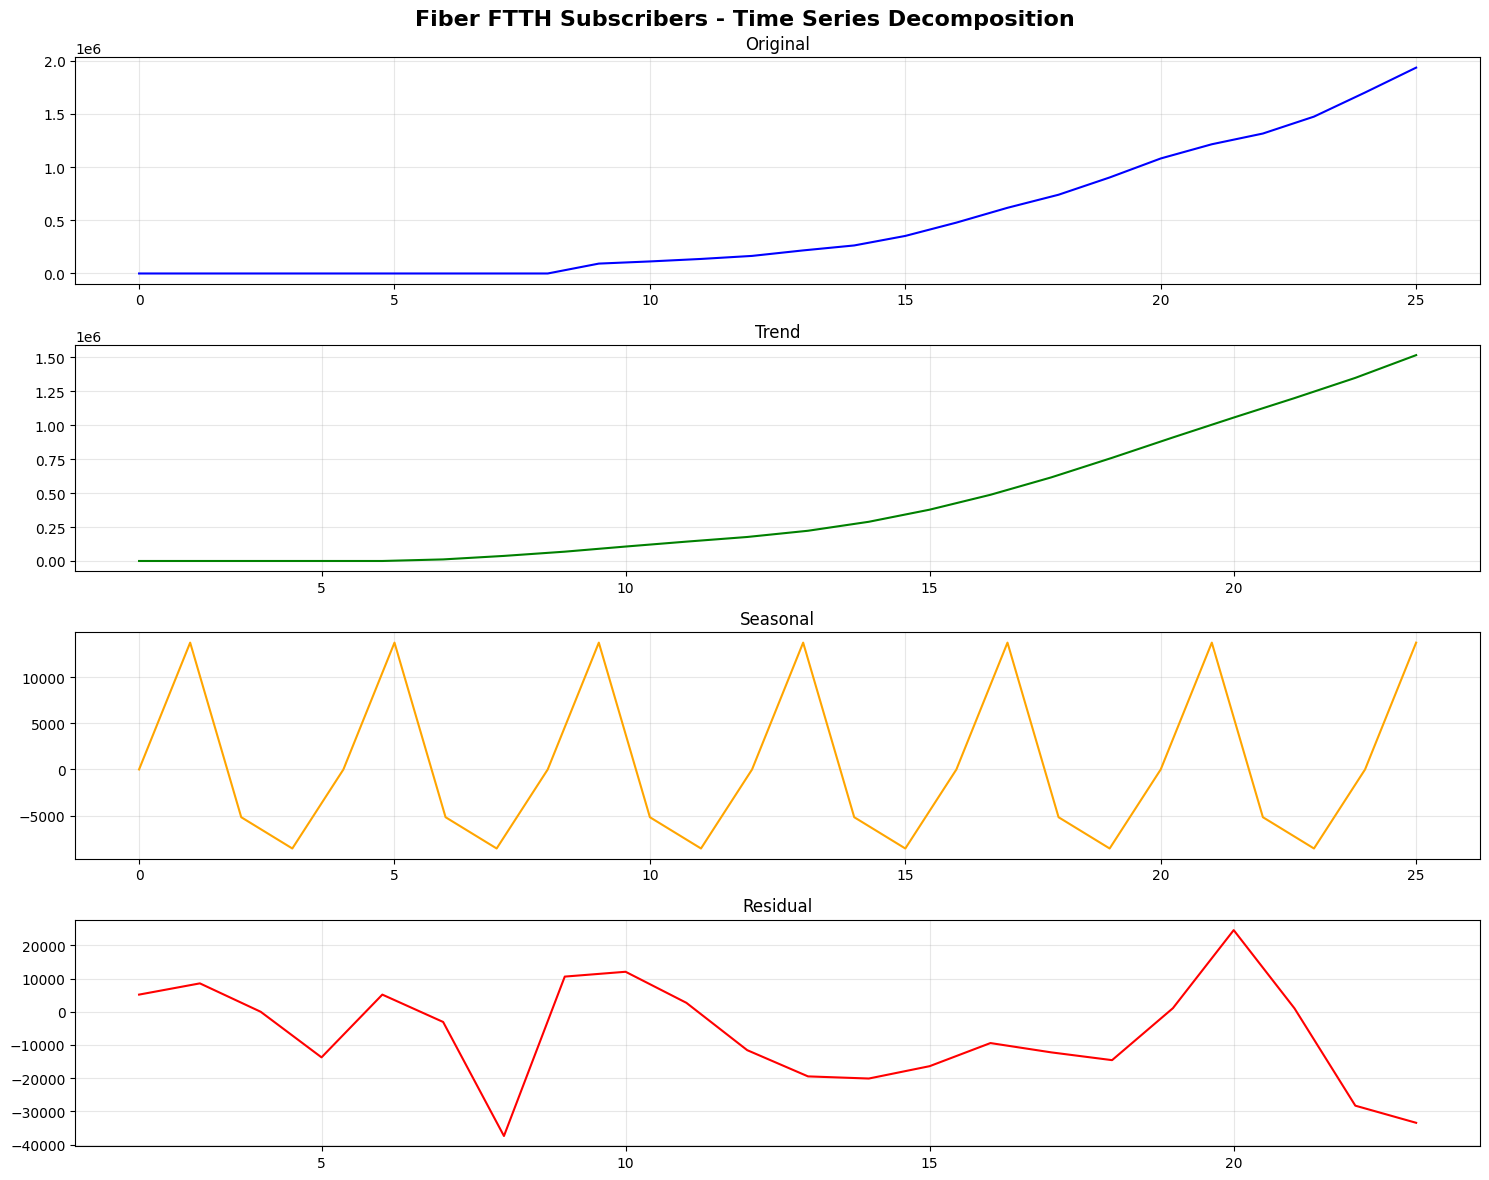

   • Seasonal Strength: 0.242

 Training Multiple Forecasting Models:
   ❌ ARIMA Model failed: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject
   ✅ Exponential Smoothing: MAE = 559547.65
   ✅ Neural Network (LSTM): MAE = 286141.10
   ✅ XGBoost: MAE = 451466.67

 Model Performance Comparison:
   🥇 Neural Network: MAE = 286141.10
   🥈 XGBoost: MAE = 451466.67
   🥉 Exponential Smoothing: MAE = 559547.65

✅ Best Model: Neural Network

🔮 Future Forecasting (Next 8 quarters):
   📊 Current Value: 1934620
   📈 2-Year Forecast: 1964423
   📊 Expected Growth: +1.5%


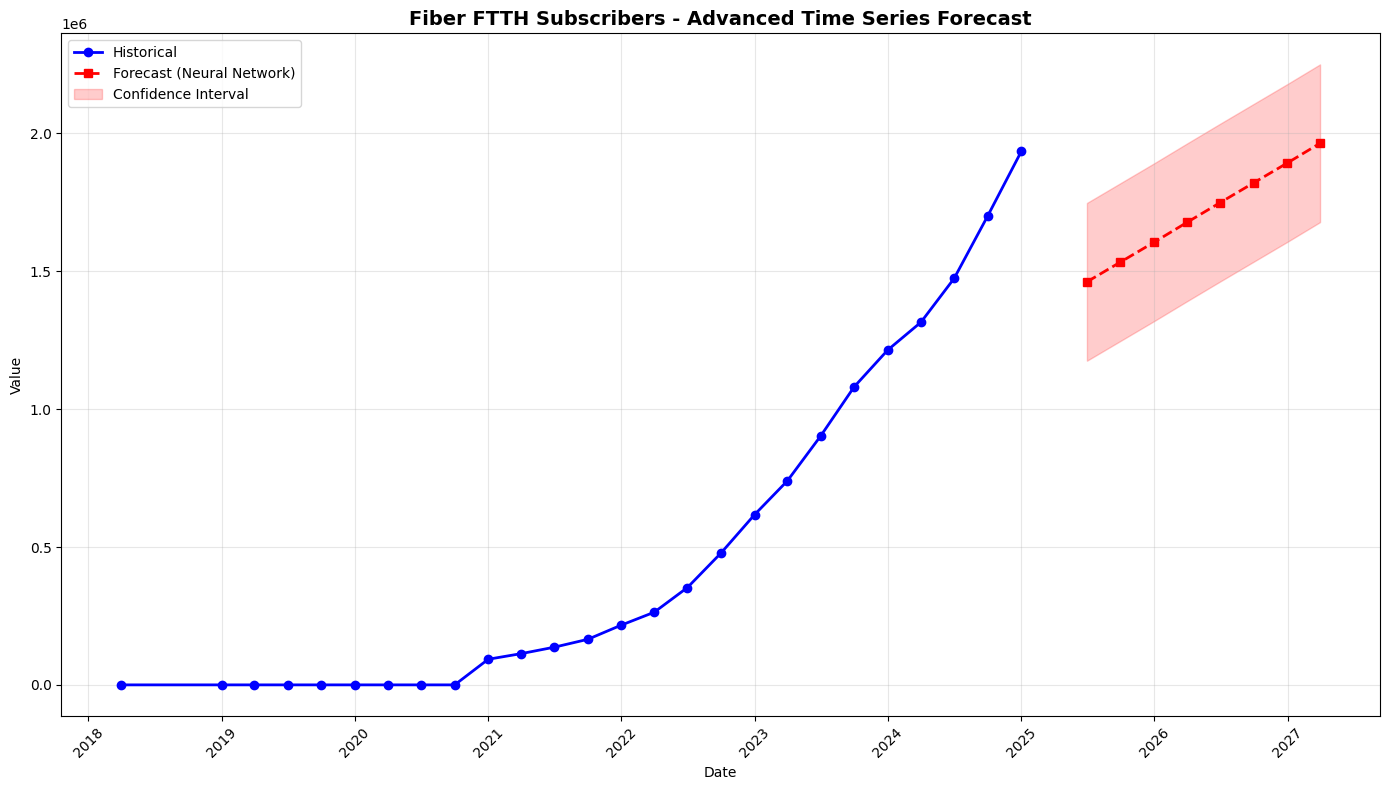

In [ ]:
fiber_ts = advanced_time_series_analysis_single(df, 'Fiber_FTTH_Subscribers', 'Fiber FTTH Subscribers')

## **8.2 ADVANCED TIME SERIES FORECASTING - TOTAL TRAFFIC CONSUMED**

 ADVANCED TIME SERIES FORECASTING: TOTAL TRAFFIC CONSUMED
📊 Data Overview:
   • Data points: 26
   • Time span: 2018-04 to 2025-01

📈 Statistical Analysis:
   • ADF Test p-value: 0.7987 (Non-stationary)


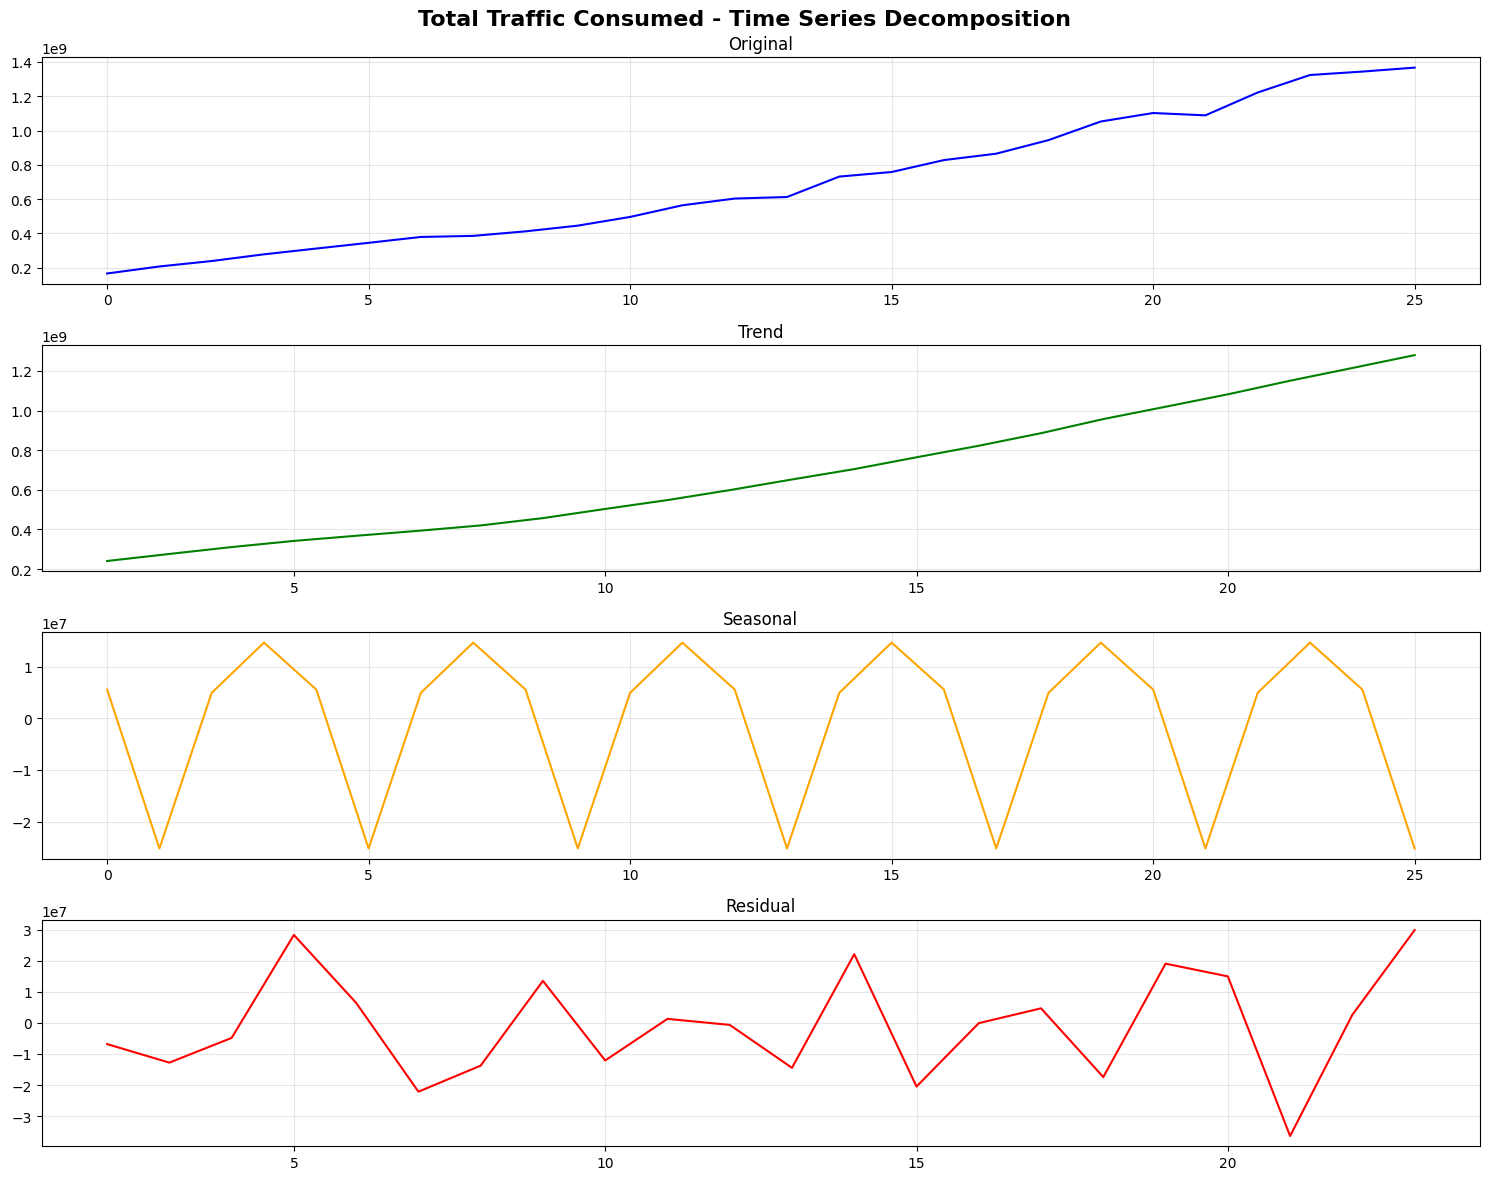

   • Seasonal Strength: 0.466

 Training Multiple Forecasting Models:
   ❌ ARIMA Model failed: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject
   ✅ Exponential Smoothing: MAE = 193811797.38
   ✅ Neural Network (LSTM): MAE = 92859672.00
   ✅ XGBoost: MAE = 173645520.00

 Model Performance Comparison:
   🥇 Neural Network: MAE = 92859672.00
   🥈 XGBoost: MAE = 173645520.00
   🥉 Exponential Smoothing: MAE = 193811797.38

✅ Best Model: Neural Network

🔮 Future Forecasting (Next 8 quarters):
   📊 Current Value: 1366893341
   📈 2-Year Forecast: 1710541714
   📊 Expected Growth: +25.1%


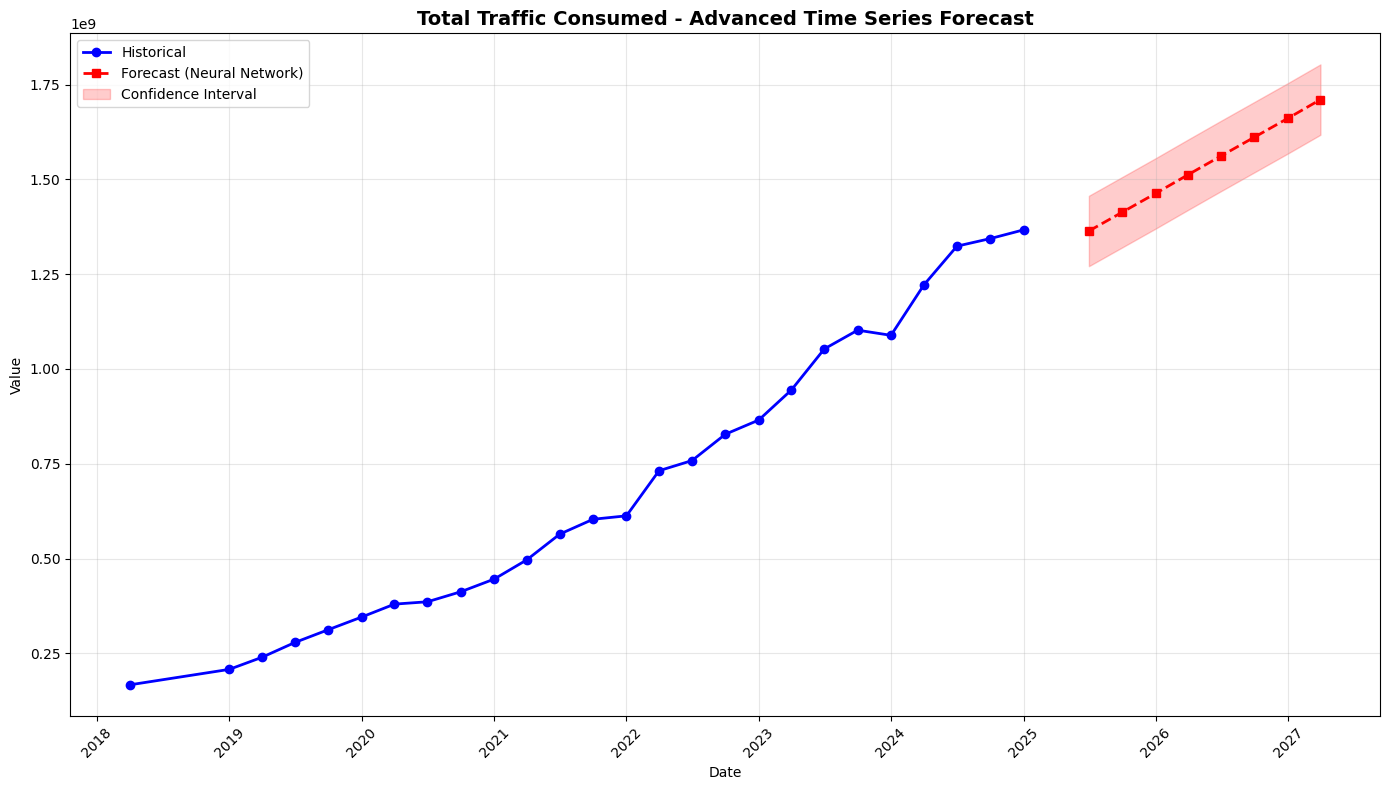

In [ ]:
traffic_ts = advanced_time_series_analysis_single(df, 'Total_Traffic_Consumed', 'Total Traffic Consumed')

## **8.3 Advanced Time Series Analysis for 4G Mobile Subscribers**

 ADVANCED TIME SERIES FORECASTING: 4G MOBILE SUBSCRIBERS
📊 Data Overview:
   • Data points: 26
   • Time span: 2018-04 to 2025-01

📈 Statistical Analysis:
   • ADF Test p-value: 0.3315 (Non-stationary)


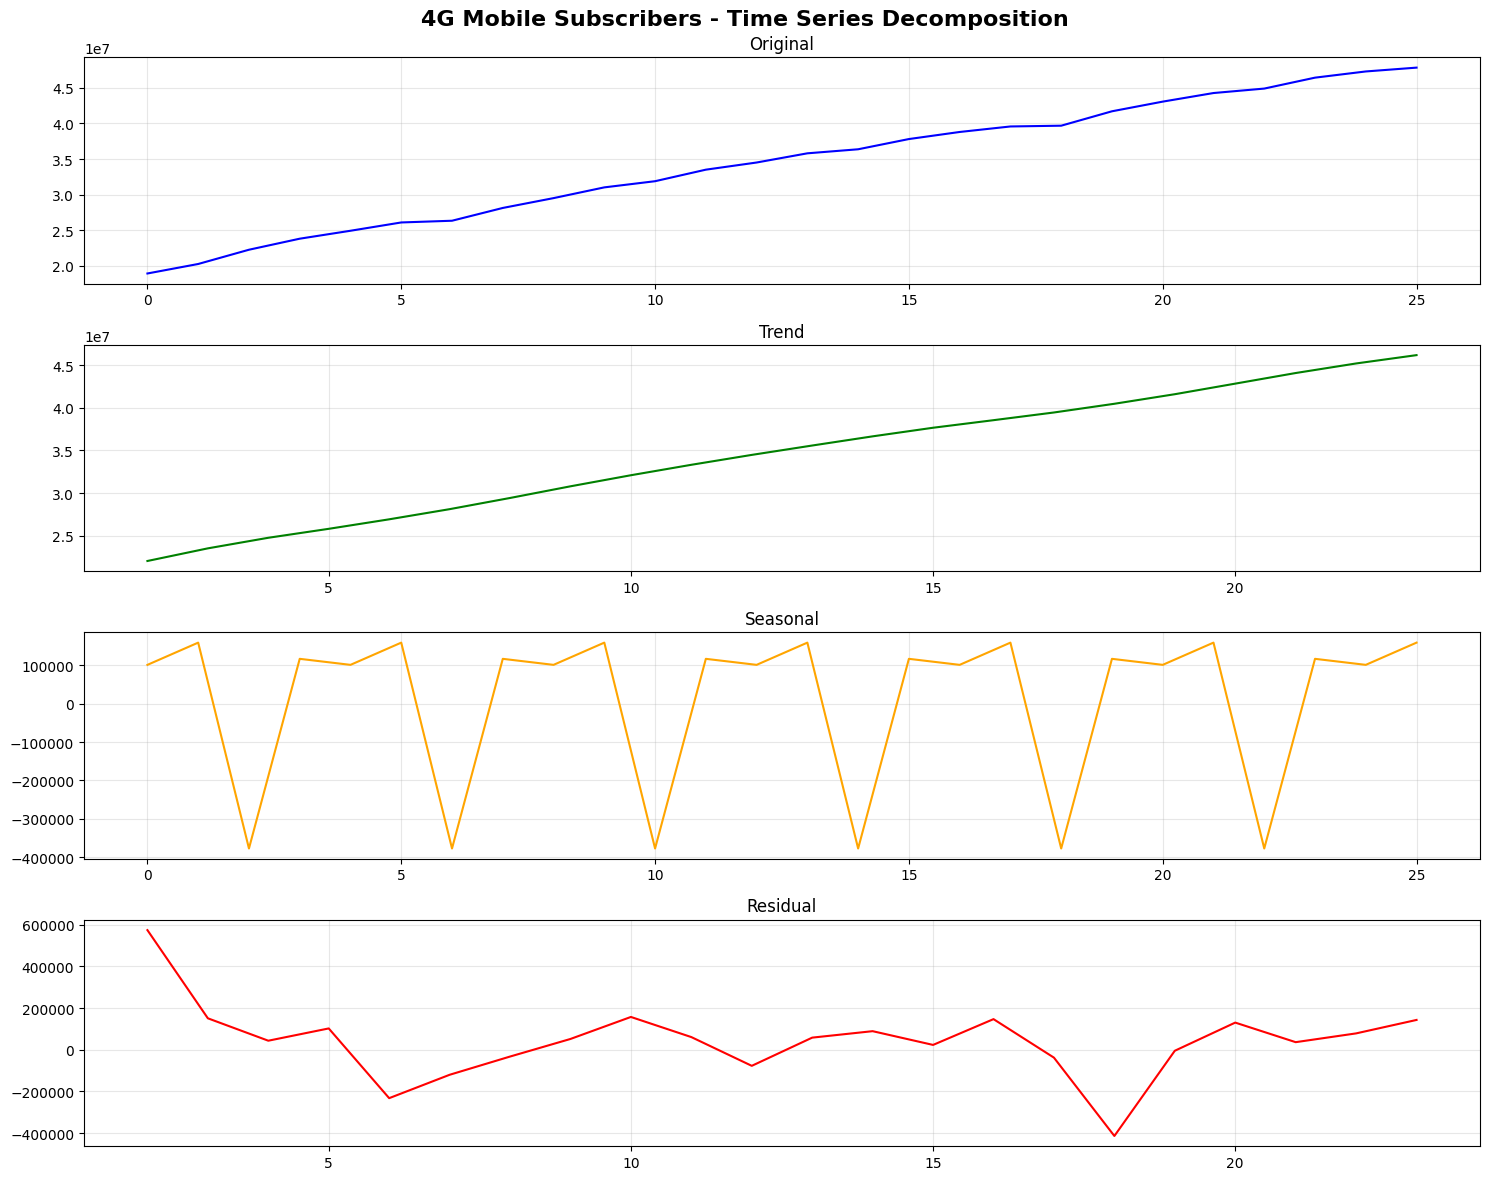

   • Seasonal Strength: 0.558

 Training Multiple Forecasting Models:
   ❌ ARIMA Model failed: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject
   ✅ Exponential Smoothing: MAE = 4145068.59
   ✅ Neural Network (LSTM): MAE = 2413871.25
   ✅ XGBoost: MAE = 3134541.50

 Model Performance Comparison:
   🥇 Neural Network: MAE = 2413871.25
   🥈 XGBoost: MAE = 3134541.50
   🥉 Exponential Smoothing: MAE = 4145068.59

✅ Best Model: Neural Network

🔮 Future Forecasting (Next 8 quarters):
   📊 Current Value: 47836371
   📈 2-Year Forecast: 57874001
   📊 Expected Growth: +21.0%


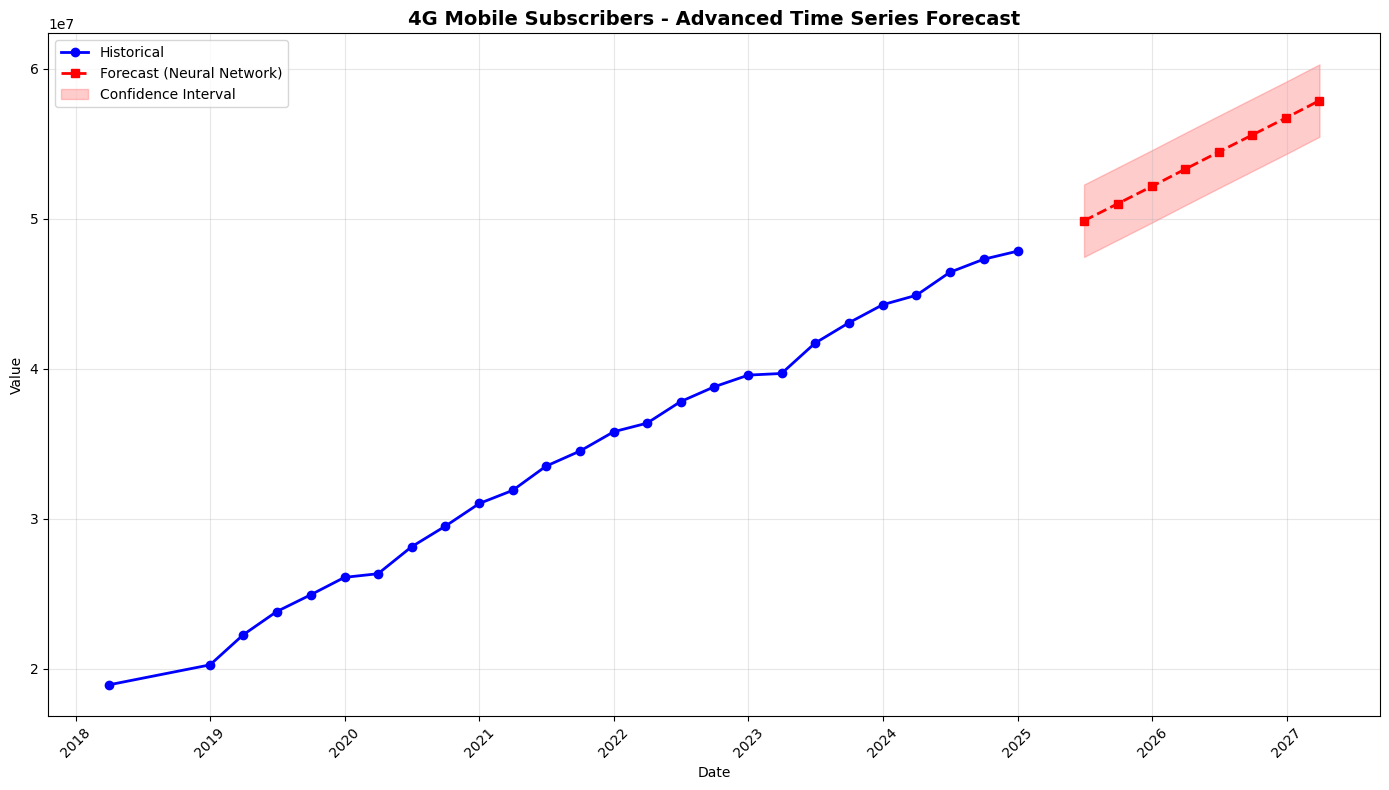

In [ ]:
mobile_4g_ts = advanced_time_series_analysis_single(df, '4G_Subscribers', '4G Mobile Subscribers')

# **9. ANOMALY DETECTION FOR DATA TRAFFIC**

 ANOMALY DETECTION: DATA TRAFFIC ANALYSIS
📊 Analyzing 26 data points for anomalies...

📊 Anomaly Detection Results:
   • Statistical Outliers (Z-score > 2.5): 0 periods
   • Isolation Forest Anomalies: 3 periods
   • IQR Outliers: 0 periods
   • Growth Rate Anomalies: 1 periods
   • Combined Anomalies (≥2 methods): 0 periods

✅ No significant anomalies detected in data traffic patterns

 Anomaly Analysis Details:
    Growth Pattern Changes: 2 periods with significant acceleration/deceleration


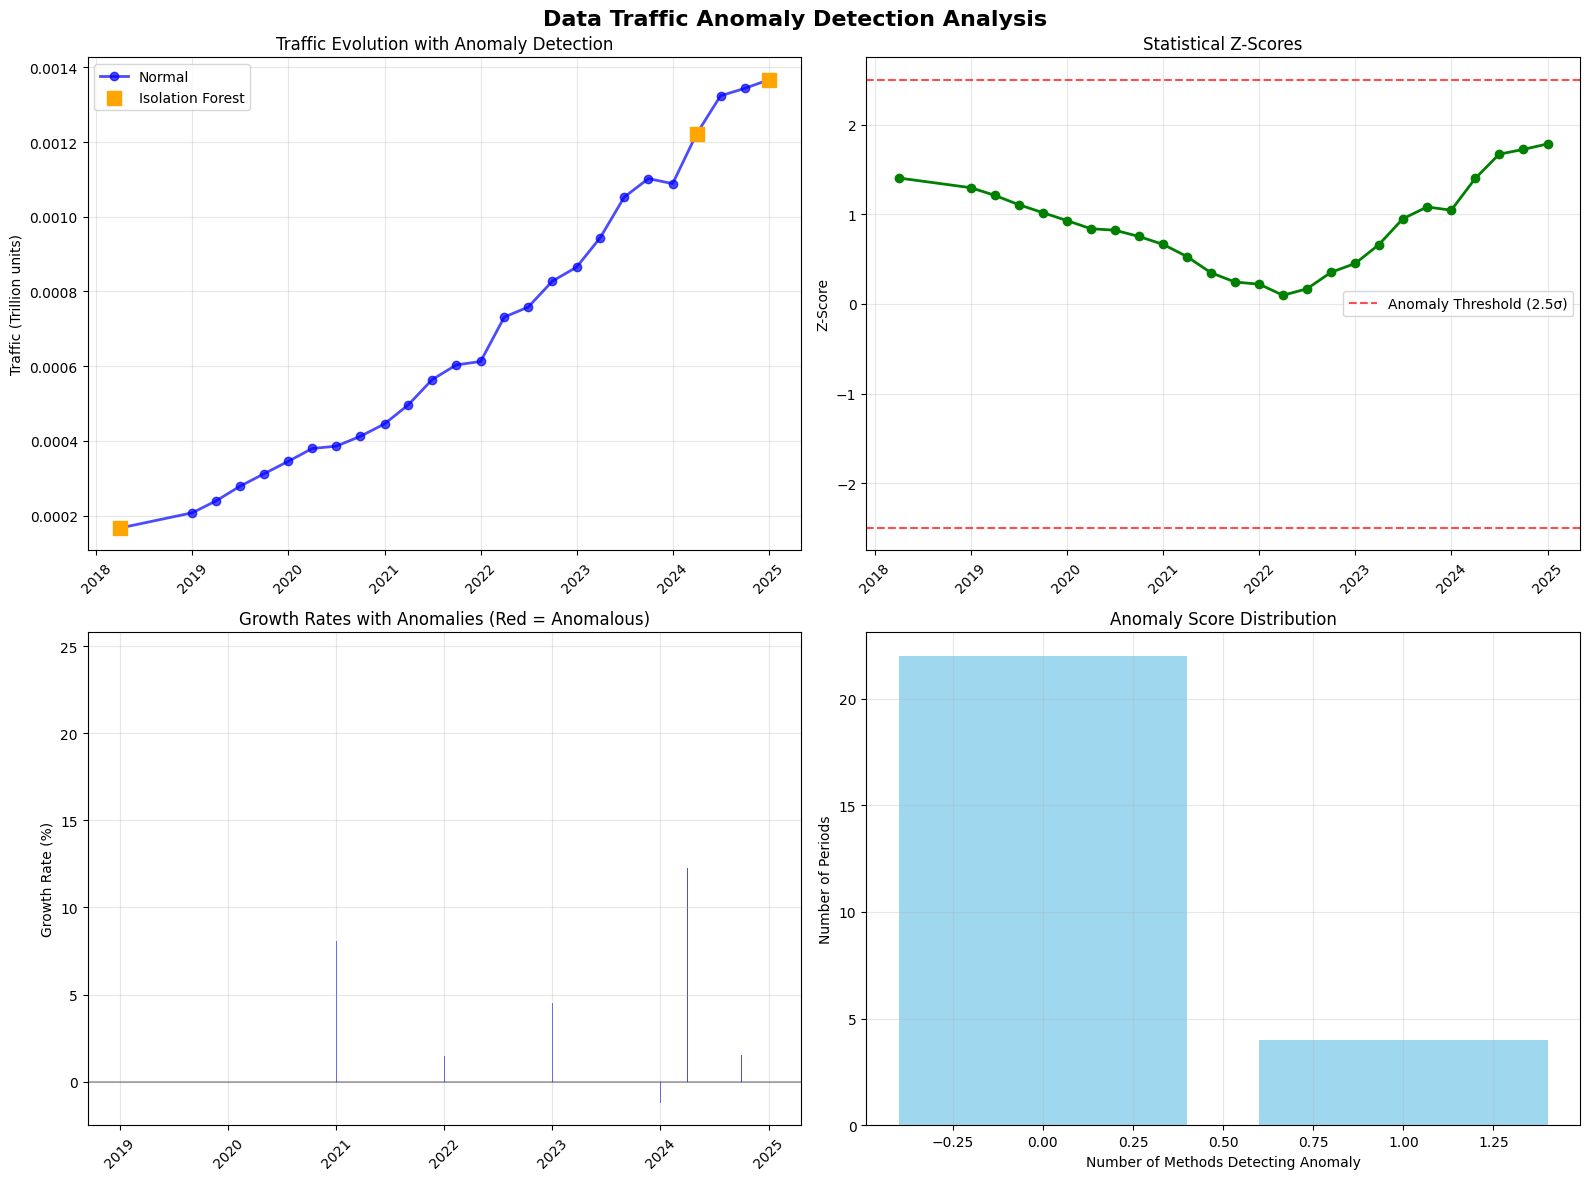


 Business Impact Analysis:


In [ ]:
def data_traffic_anomaly_detection(df):
    """Comprehensive anomaly detection for data traffic"""

    print(" ANOMALY DETECTION: DATA TRAFFIC ANALYSIS")
    print("="*50)

    metric = 'Total_Traffic_Consumed'
    data = df[metric]

    print(f"📊 Analyzing {len(data)} data points for anomalies...")

    # Method 1: Statistical Outliers (Z-score)
    z_scores = np.abs(stats.zscore(data))
    statistical_outliers = z_scores > 2.5  # 2.5 standard deviations

    # Method 2: Isolation Forest
    iso_forest = IsolationForest(contamination=0.1, random_state=42)
    isolation_outliers = iso_forest.fit_predict(data.values.reshape(-1, 1)) == -1

    # Method 3: Interquartile Range (IQR)
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    iqr_outliers = (data < (Q1 - 1.5 * IQR)) | (data > (Q3 + 1.5 * IQR))

    # Method 4: Growth Rate Anomalies
    growth_rates = data.pct_change() * 100
    growth_z_scores = np.abs(stats.zscore(growth_rates.dropna()))
    growth_outliers = growth_z_scores > 2.0
    growth_outliers_full = np.zeros(len(data), dtype=bool)
    growth_outliers_full[1:] = growth_outliers

    # Combine methods (anomaly if detected by at least 2 methods)
    combined_anomalies = (statistical_outliers.astype(int) +
                         isolation_outliers.astype(int) +
                         iqr_outliers.astype(int) +
                         growth_outliers_full.astype(int)) >= 2

    anomaly_periods = df.loc[combined_anomalies, 'Period'].tolist()

    print(f"\n📊 Anomaly Detection Results:")
    print(f"   • Statistical Outliers (Z-score > 2.5): {statistical_outliers.sum()} periods")
    print(f"   • Isolation Forest Anomalies: {isolation_outliers.sum()} periods")
    print(f"   • IQR Outliers: {iqr_outliers.sum()} periods")
    print(f"   • Growth Rate Anomalies: {growth_outliers_full.sum()} periods")
    print(f"   • Combined Anomalies (≥2 methods): {combined_anomalies.sum()} periods")

    if anomaly_periods:
        print(f"\n Anomalous Periods Identified:")
        for period in anomaly_periods:
            period_idx = df[df['Period'] == period].index[0]
            value = df.loc[period_idx, metric]

            # Compare to trend
            if period_idx > 0:
                prev_value = df.loc[period_idx - 1, metric]
                change = ((value - prev_value) / prev_value) * 100
                change_status = "📈" if change > 10 else "📉" if change < -10 else "📊"
                print(f"   {change_status} {period}: {value:,.0f} units ({change:+.1f}% vs previous)")
            else:
                print(f"   📊 {period}: {value:,.0f} units (first period)")
    else:
        print(f"\n✅ No significant anomalies detected in data traffic patterns")

    # Detailed anomaly analysis
    print(f"\n Anomaly Analysis Details:")

    # Traffic surge analysis
    surge_threshold = data.mean() + 2 * data.std()
    surge_periods = data[data > surge_threshold]

    if len(surge_periods) > 0:
        print(f"   📈 Traffic Surge Events: {len(surge_periods)} periods above {surge_threshold/1e12:.1f}T units")
        for idx in surge_periods.index:
            period = df.loc[idx, 'Period']
            value = surge_periods.loc[idx]
            print(f"      • {period}: {value/1e12:.1f}T units")

    # Traffic drop analysis
    drop_threshold = data.mean() - 2 * data.std()
    if drop_threshold > 0:
        drop_periods = data[data < drop_threshold]
        if len(drop_periods) > 0:
            print(f"   📉 Traffic Drop Events: {len(drop_periods)} periods below {drop_threshold/1e12:.1f}T units")

    # Growth acceleration/deceleration
    growth_acceleration = growth_rates.diff()
    accel_anomalies = np.abs(growth_acceleration) > growth_acceleration.std() * 2
    accel_periods = df.loc[accel_anomalies.fillna(False), 'Period'].tolist()

    if accel_periods:
        print(f"    Growth Pattern Changes: {len(accel_periods)} periods with significant acceleration/deceleration")

    # Comprehensive visualization
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Data Traffic Anomaly Detection Analysis', fontsize=16, fontweight='bold')

    # Plot 1: Time series with anomalies highlighted
    ax1 = axes[0, 0]
    ax1.plot(df['Date'], data/1e12, marker='o', linewidth=2, label='Normal', color='blue', alpha=0.7)

    # Highlight different types of anomalies
    if statistical_outliers.any():
        stat_anomalies = df.loc[statistical_outliers]
        ax1.scatter(stat_anomalies['Date'], stat_anomalies[metric]/1e12,
                   color='red', s=100, label='Statistical Outliers', zorder=5, marker='^')

    if isolation_outliers.any():
        iso_anomalies = df.loc[isolation_outliers]
        ax1.scatter(iso_anomalies['Date'], iso_anomalies[metric]/1e12,
                   color='orange', s=100, label='Isolation Forest', zorder=5, marker='s')

    if combined_anomalies.any():
        combined_anomaly_data = df.loc[combined_anomalies]
        ax1.scatter(combined_anomaly_data['Date'], combined_anomaly_data[metric]/1e12,
                   color='purple', s=150, label='Combined Anomalies', zorder=6, marker='*')

    ax1.set_title('Traffic Evolution with Anomaly Detection')
    ax1.set_ylabel('Traffic (Trillion units)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.tick_params(axis='x', rotation=45)

    # Plot 2: Z-scores over time
    ax2 = axes[0, 1]
    ax2.plot(df['Date'], z_scores, marker='o', linewidth=2, color='green')
    ax2.axhline(y=2.5, color='red', linestyle='--', alpha=0.7, label='Anomaly Threshold (2.5σ)')
    ax2.axhline(y=-2.5, color='red', linestyle='--', alpha=0.7)
    ax2.set_title('Statistical Z-Scores')
    ax2.set_ylabel('Z-Score')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.tick_params(axis='x', rotation=45)

    # Plot 3: Growth rates with anomalies
    ax3 = axes[1, 0]
    colors = ['red' if x else 'blue' for x in growth_outliers_full]
    ax3.bar(df['Date'][1:], growth_rates[1:], color=colors[1:], alpha=0.7)
    ax3.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    ax3.set_title('Growth Rates with Anomalies (Red = Anomalous)')
    ax3.set_ylabel('Growth Rate (%)')
    ax3.grid(True, alpha=0.3)
    ax3.tick_params(axis='x', rotation=45)

    # Plot 4: Anomaly score distribution
    ax4 = axes[1, 1]
    anomaly_scores = (statistical_outliers.astype(int) +
                     isolation_outliers.astype(int) +
                     iqr_outliers.astype(int) +
                     growth_outliers_full.astype(int))

    score_counts = np.bincount(anomaly_scores)
    ax4.bar(range(len(score_counts)), score_counts, color='skyblue', alpha=0.8)
    ax4.set_title('Anomaly Score Distribution')
    ax4.set_xlabel('Number of Methods Detecting Anomaly')
    ax4.set_ylabel('Number of Periods')
    ax4.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Business impact analysis
    print(f"\n Business Impact Analysis:")

    if combined_anomalies.any():
        anomaly_data = df.loc[combined_anomalies, metric]
        normal_data = df.loc[~combined_anomalies, metric]

        avg_normal_traffic = normal_data.mean()
        avg_anomaly_traffic = anomaly_data.mean()

        impact = ((avg_anomaly_traffic - avg_normal_traffic) / avg_normal_traffic) * 100

        print(f"   • Average Normal Traffic: {avg_normal_traffic/1e12:.2f}T units")
        print(f"   • Average Anomaly Traffic: {avg_anomaly_traffic/1e12:.2f}T units")
        print(f"   • Average Impact: {impact:+.1f}% deviation from normal")

        # Capacity planning insights
        max_anomaly = anomaly_data.max()
        capacity_requirement = (max_anomaly / avg_normal_traffic) * 100
        print(f"   • Peak Anomaly Event: {max_anomaly/1e12:.2f}T units")
        print(f"   • Capacity Planning: Need {capacity_requirement:.0f}% of normal capacity for peak events")

    return {
        'anomaly_periods': anomaly_periods,
        'total_anomalies': combined_anomalies.sum(),
        'anomaly_methods': {
            'statistical': statistical_outliers.sum(),
            'isolation_forest': isolation_outliers.sum(),
            'iqr': iqr_outliers.sum(),
            'growth_rate': growth_outliers_full.sum()
        }
    }

# Run data traffic anomaly detection
traffic_anomaly_results = data_traffic_anomaly_detection(df)